In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import altair as alt
import seaborn as sns
from scipy import stats
import numpy as np

In [2]:
# set Times New Roman as the default font for figure plotting
plt.rcParams['font.family'] = 'Times New Roman'

In [3]:
def tnr():
    font = "Times New Roman"
    
    return {
        "config" : {
             "title": {'font': font},
             "axis": {
                  "labelFont": font,
                  "titleFont": font
             },
             "header": {
                  "labelFont": font,
                  "titleFont": font
             },
             "legend": {
                  "labelFont": font,
                  "titleFont": font
             }
        }
    }

In [4]:
alt.themes.register('tnr', tnr)
alt.themes.enable('tnr')

ThemeRegistry.enable('tnr')

### 1. Import the metadata table of 267 samples, MTB bins feature table, read recruitment result table

In [5]:
meta_df = pd.read_excel('Tables/TableS1_metadata_of_sample.xlsx')
meta_df.set_index('sample_id',inplace=True)
meta_df

,Run,site name,Lake-code,geographic location (country and/or sea),environment (biome),environment (feature),environment (material),geographic location (depth),geographic location (latitude),geographic location (longitude),...,ice thickness,nitrate+nitrite,chlorophyll,ENA-CHECKLIST,sequencing method,investigation type,sample contact,project name,collection data,water environmental package
sample_id,,,,,,,,,,,,,,,,,,,,,
AM-lipid-01-D1,R2,Alinen Mustajärvi,AM,Finland,lentic water body,lake,water,1.0,61.21,25.11,...,NaN,NaN,NaN,ERC000024,NovaSeq,metagenome,Sari Peura,microbes in stratified freshwaters,metagenome,water
AM-lipid-01-D2,R2,Alinen Mustajärvi,AM,Finland,lentic water body,lake,water,2.0,61.21,25.11,...,NaN,NaN,NaN,ERC000024,NovaSeq,metagenome,Sari Peura,microbes in stratified freshwaters,metagenome,water
AM-lipid-01-D3,R2,Alinen Mustajärvi,AM,Finland,lentic water body,lake,water,2.3,61.21,25.11,...,NaN,NaN,NaN,ERC000024,NovaSeq,metagenome,Sari Peura,microbes in stratified freshwaters,metagenome,water
AM-lipid-01-D10,R2,Alinen Mustajärvi,AM,Finland,lentic water body,lake,water,6.0,61.21,25.11,...,NaN,NaN,NaN,ERC000024,NovaSeq,metagenome,Sari Peura,microbes in stratified freshwaters,metagenome,water
AM4,R1,Alinen Mustajärvi,AM,Finland,lentic water body,lake,water,4.0,61.21,25.11,...,NaN,NaN,NaN,ERC000024,NovaSeq,metagenome,Leyden Fernandez,microbes in stratified freshwaters,metagenome,water
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VK4,R1,Valkea Kotinen,VK,Finland,lentic water body,lake,water,4.5,61.24,25.06,...,NaN,NaN,NaN,ERC000024,NovaSeq,metagenome,Leyden Fernandez,microbes in stratified freshwaters,metagenome,water
YR3,R1,Ylinen Rajajärvi,YR,Finland,lentic water body,lake,water,4.0,61.22,25.21,...,NaN,NaN,NaN,ERC000024,NovaSeq,metagenome,Leyden Fernandez,microbes in stratified freshwaters,metagenome,water
YR1,R1,Ylinen Rajajärvi,YR,Finland,lentic water body,lake,water,0.5,61.22,25.21,...,NaN,NaN,NaN,ERC000024,NovaSeq,metagenome,Leyden Fernandez,microbes in stratified freshwaters,metagenome,water


In [6]:
MTB_bin_feature_df=pd.read_excel('Tables/TableS2_genomic_feature_of_63_MTB_MAG.xlsx')
MTB_bin_feature_df['phylum'] = MTB_bin_feature_df.classification.apply(lambda x: ';'.join(x.split(';')[1:3]) if 'Proteo' in x else x.split(';')[1])
MTB_bin_feature_df

,MTB MAG,# contigs,Largest contig,Total length,GC (%),N50,L50,Completeness,Contamination,classification,Quality,phylum
0,SFLP_MTB_A3_bin18,190,155390,3694317,51.56,31972,36,83.87,0.90,d__Bacteria;p__Desulfobacterota;c__Desulfuromo...,Medium,p__Desulfobacterota
1,SFLP_MTB_A4_bin1,209,100943,5003715,55.24,40527,41,92.60,4.09,d__Bacteria;p__Desulfobacterota;c__Desulfuromo...,High,p__Desulfobacterota
2,SFLP_MTB_A4_bin21,84,367656,4661276,50.58,104191,13,99.35,0.97,d__Bacteria;p__Desulfobacterota;c__Desulfuromo...,High,p__Desulfobacterota
3,SFLP_MTB_AM-2014-D3_bin8,1238,27851,4097361,63.26,3167,408,53.83,9.59,d__Bacteria;p__Proteobacteria;c__Alphaproteoba...,Medium,p__Proteobacteria;c__Alphaproteobacteria
4,SFLP_MTB_AM-2014-D4_bin5,564,45639,5220492,64.90,11758,141,89.55,0.79,d__Bacteria;p__Proteobacteria;c__Alphaproteoba...,Medium,p__Proteobacteria;c__Alphaproteobacteria
...,...,...,...,...,...,...,...,...,...,...,...,...
58,SFLP_MTB_Umea3p4_bin32,491,45785,2967519,60.88,7202,126,87.10,0.36,d__Bacteria;p__Proteobacteria;c__Alphaproteoba...,Medium,p__Proteobacteria;c__Alphaproteobacteria
59,SFLP_MTB_Umea3p4_bin52,702,34886,3160004,57.78,4840,200,76.27,0.96,d__Bacteria;p__Proteobacteria;c__Magnetococcia...,Medium,p__Proteobacteria;c__Magnetococcia
60,SFLP_MTB_VK2_bin2,158,174603,4888818,65.42,53920,28,99.50,1.16,d__Bacteria;p__Proteobacteria;c__Alphaproteoba...,High,p__Proteobacteria;c__Alphaproteobacteria
61,SFLP_MTB_VK2_bin28,701,17743,2471252,64.32,3651,231,55.25,1.99,d__Bacteria;p__Proteobacteria;c__Alphaproteoba...,Medium,p__Proteobacteria;c__Alphaproteobacteria


In [7]:
# import the detection table
detec_df = pd.read_excel('Tables/TableS3_anvio_detection_result.xlsx').T
detec_df = detec_df.rename(columns=detec_df.iloc[0]).iloc[1:,:]
detec_df

,SFLP_MTB_A4_bin1,SFLP_MTB_A4_bin21,SFLP_MTB_AM5_bin22,SFLP_MTB_AM-2014-D3_bin8,SFLP_MTB_AM-2014-D4_bin6,SFLP_MTB_AM-2014-D8_bin43,SFLP_MTB_AM-lipid-01-D7_bin11,SFLP_MTB_AM-lipid-02-D5_bin1,SFLP_MTB_AM-lipid-02-D5_bin20,SFLP_MTB_Day2-5_bin11,...,SFLP_MTB_Loc080925-5-5m_bin37,SFLP_MTB_Loc090519-8-7m_bin35,SFLP_MTB_Loc090721-6m_bin27,SFLP_MTB_MJ4_bin9,SFLP_MTB_Umea1p4_bin7,SFLP_MTB_Umea3p3_bin40,SFLP_MTB_Umea3p4_bin52,SFLP_MTB_VK2_bin2,SFLP_MTB_VK2_bin28,SFLP_MTB_VK3_bin11
A1,0.023354,0.039823,0.022037,0.00702,0.019819,0.078059,0.007037,0.005786,0.004242,0.00083,...,0.005168,0.008441,0.000808,0.164672,0.002077,0.00087,0.000237,0.014443,0.002954,0.01143
A2,0.220598,0.753882,0.028401,0.015538,0.04917,0.115685,0.024982,0.030413,0.015037,0.004298,...,0.024992,0.035192,0.002602,0.235758,0.006111,0.002106,0.000739,0.291199,0.017483,0.02594
A3,0.993805,0.999257,0.02566,0.013651,0.039223,0.11792,0.040231,0.074428,0.019111,0.006319,...,0.017647,0.038407,0.00308,0.244983,0.006228,0.001486,0.000345,0.434937,0.160847,0.023494
A4,0.999659,0.999948,0.024372,0.010509,0.03243,0.119065,0.031066,0.112359,0.009933,0.007703,...,0.00972,0.037413,0.002731,0.266866,0.007624,0.001074,0.000454,0.203929,0.033492,0.022505
A5,0.035276,0.066298,0.002615,0.060985,0.02022,0.005829,0.001439,0.005976,0.019143,0.000548,...,0.01164,0.001021,0.000161,0.00736,0.00114,0.001086,0.000311,0.021959,0.009927,0.011591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VK4,0.163995,0.018952,0.02445,0.152391,0.154955,0.051498,0.00642,0.117964,0.009989,0.073206,...,0.009512,0.004269,0.033771,0.059611,0.085919,0.071497,0.004537,0.208225,0.006516,0.326196
YR1,0.000363,0.001709,0.00308,0.020468,0.007038,0.006876,0.000329,0.00369,0.002854,0.002322,...,0.003332,0.000117,0.000289,0.011894,0.001821,0.002864,0.000276,0.016556,0.00424,0.008166
YR2,0.018536,0.024639,0.020284,0.044537,0.103029,0.043906,0.003278,0.081849,0.429443,0.006561,...,0.012346,0.000106,0.001182,0.07662,0.006808,0.007061,0.00083,0.111225,0.09656,0.04269
YR3,0.003162,0.006929,0.003416,0.110617,0.169075,0.002908,0.000711,0.354724,0.030701,0.004271,...,0.007365,0.000364,0.000248,0.004783,0.004362,0.035603,0.001047,0.060487,0.015368,0.097642


In [8]:
# import the mean_coverage_Q2Q3 table
q2q3_mc_df = pd.read_excel('Tables/TableS4_anvio_mean_coverage_Q2Q3_result.xlsx').T
q2q3_mc_df = q2q3_mc_df.rename(columns=q2q3_mc_df.iloc[0]).iloc[1:,:]
q2q3_mc_df

,SFLP_MTB_A4_bin1,SFLP_MTB_A4_bin21,SFLP_MTB_AM5_bin22,SFLP_MTB_AM-2014-D3_bin8,SFLP_MTB_AM-2014-D4_bin6,SFLP_MTB_AM-2014-D8_bin43,SFLP_MTB_AM-lipid-01-D7_bin11,SFLP_MTB_AM-lipid-02-D5_bin1,SFLP_MTB_AM-lipid-02-D5_bin20,SFLP_MTB_Day2-5_bin11,...,SFLP_MTB_Loc080925-5-5m_bin37,SFLP_MTB_Loc090519-8-7m_bin35,SFLP_MTB_Loc090721-6m_bin27,SFLP_MTB_MJ4_bin9,SFLP_MTB_Umea1p4_bin7,SFLP_MTB_Umea3p3_bin40,SFLP_MTB_Umea3p4_bin52,SFLP_MTB_VK2_bin2,SFLP_MTB_VK2_bin28,SFLP_MTB_VK3_bin11
A1,0.001347,0.0,0.005208,0.000005,0.0,0.019549,0.0,0.0,0.0,0.0,...,0.0,0.000486,0.0,0.162409,0.000129,0.0,0.0,0.000046,0.0,0.0
A2,0.035259,1.957788,0.014543,0.003349,0.015323,0.065713,0.0,0.008768,0.001841,0.002154,...,0.00063,0.010394,0.0,0.476763,0.007095,0.0,0.0,0.320307,0.001403,0.000011
A3,8.124782,14.038037,0.014948,0.001766,0.008111,0.078626,0.0,0.145208,0.001179,0.0108,...,0.000118,0.015445,0.000163,0.570842,0.056794,0.0,0.0,0.54731,0.048424,0.000872
A4,17.238625,60.471836,0.019935,0.001601,0.001653,0.082844,0.0,0.347875,0.000072,0.04766,...,0.0,0.012004,0.000237,0.654408,0.221642,0.0,0.0,0.023055,0.000048,0.000751
A5,0.0,0.00001,0.00156,0.036332,0.001604,0.0,0.0,0.000815,0.002013,0.000057,...,0.000172,0.0,0.0,0.0,0.000817,0.0,0.0,0.00018,0.0,0.000002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VK4,0.048763,0.009659,0.213456,0.154994,0.046518,0.0026,0.0,0.020864,0.00463,0.006428,...,0.000155,0.0,0.003036,0.017626,0.031261,0.028967,0.000043,0.036303,0.0,0.196121
YR1,0.0,0.0,0.019353,0.095377,0.027573,0.0,0.0,0.000265,0.000535,0.0,...,0.0,0.0,0.0,0.0,0.0,0.001669,0.0,0.0,0.000315,0.0
YR2,0.000068,0.017422,0.03198,0.158653,0.063596,0.003156,0.0,0.432662,0.66455,0.008301,...,0.0,0.0,0.0,0.046705,0.00568,0.013003,0.000081,0.007193,0.009254,0.000688
YR3,0.0,0.000192,0.015936,0.925543,0.066602,0.0,0.0,0.288731,0.009928,0.002393,...,0.0,0.0,0.0,0.0,0.000673,0.027328,0.000085,0.012772,0.000726,0.017428


In [9]:
#import reads count data
rc_df = pd.read_excel('Tables/TableS5_read_recruitment_result.xlsx')
rc_df.set_index('sample_id',inplace=True)
rc_df

,total_reads,recruited_reads,scaling_factor
sample_id,,,
A1,33370665,40886,1.069728
A2,60228797,242769,0.592699
A3,43085200,993442,0.828534
A4,42701992,2902414,0.835969
A5,35519910,57611,1.005001
...,...,...,...
VK4,30076610,141728,1.186887
YR1,28787255,29290,1.240046
YR2,33737891,194525,1.058084


### 2. Describe the sampling locations and environments

In [10]:
# Sampling points are divided into cold zone, temperate zone and tropical zone according to latitude
North_Frigid_Zone = (66.56352, 90) #北寒带
North_Temperate_Zone = (23.43647, 66.56352)# 北温带（北回归线到北极圈之间）
Torrid_Zone = (-23.43647, 23.43647)
meta_df['latitude_zone'] = meta_df['geographic location (latitude)'].apply(lambda x: 
                                           'Frigid' if x>=66.56352 else 'Temperate' if x>=23.43647 else 'Torrid')

In [11]:
# 267 sample sites distributed in contries/locations
s_distri_df = pd.DataFrame(meta_df.loc[:,['geographic location (country and/or sea)','latitude_zone']].value_counts()).reset_index()
s_distri_df

,geographic location (country and/or sea),latitude_zone,count
0,Finland,Temperate,113
1,Sweden,Temperate,56
2,Switzerland,Temperate,44
3,Canada,Temperate,30
4,Sweden,Frigid,12
5,PuertoRico,Torrid,8
6,USA,Frigid,4


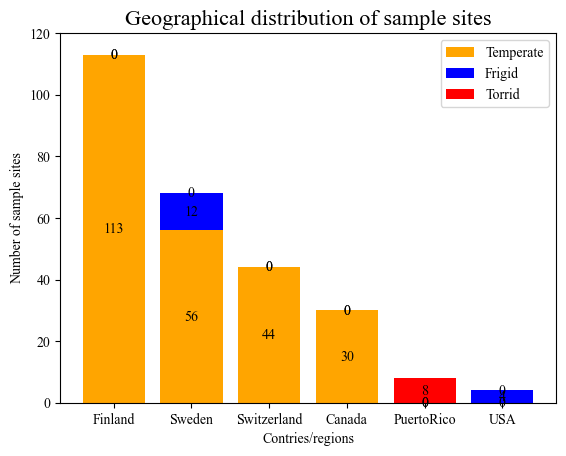

In [12]:
# generate the Geographical distribution bar plot of sample sites
contries = tuple(s_distri_df['geographic location (country and/or sea)'].unique().tolist())
zone_counts = {
    'Temperate':np.array([113,56,44,30,0,0]),
    'Frigid': np.array([0,12,0,0,0,4]),
    'Torrid':np.array([0,0,0,0,8,0])
}

width = 0.8

fig, ax = plt.subplots()
bottom = np.zeros(6)

colors=['orange','blue','red']
idx=0
for zone, zone_count in zone_counts.items():
    p = ax.bar(contries, zone_count, width, label=zone, bottom=bottom, color=colors[idx])
    ax.bar_label(p, label_type='center')
    bottom += zone_count
    idx+=1

plt.ylim(0, 120)
ax.set_ylabel('Number of sample sites')
ax.set_xlabel('Contries/regions')
ax.set_title('Geographical distribution of sample sites',fontsize=16)
ax.legend()
plt.show()

In [13]:
meta_df.loc[:,['environment (feature)','environment (material)']].value_counts()

environment (feature)  environment (material)
lake                   water                     216
pond                   water                      34
lake                   sediment                    9
reservoir              water                       8
Name: count, dtype: int64

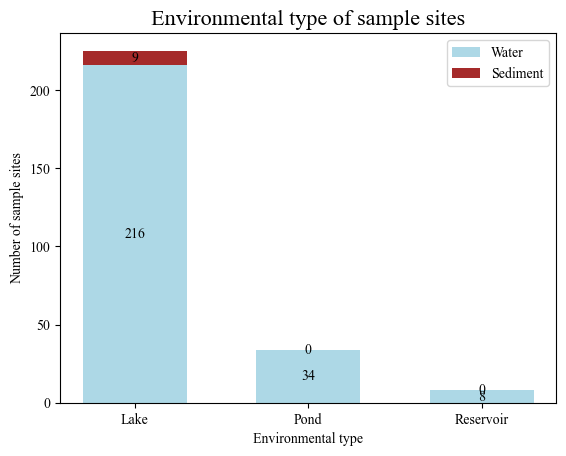

In [14]:
# generate the sample type distribution bar plot
species = ('Lake', 'Pond', 'Reservoir')
sex_counts = {
    'Water': np.array([216, 34, 8]),
    'Sediment': np.array([9, 0, 0]),
}
width = 0.6  # the width of the bars: can also be len(x) sequence


fig, ax = plt.subplots()
bottom = np.zeros(3)

color='lightblue'
for sex, sex_count in sex_counts.items():
    p = ax.bar(species, sex_count, width, label=sex, bottom=bottom, color=color)
    bottom += sex_count
    color='brown'

    ax.bar_label(p, label_type='center')
ax.set_ylabel('Number of sample sites')
ax.set_xlabel('Environmental type')
ax.set_title('Environmental type of sample sites',fontsize=16)
ax.legend()

# ax.get_figure().savefig('Figures/F1c_environmental_type_of_267_sample_sites.svg',bbox_inches='tight')
plt.show()

### 3. Profile MTB community distribution across 267 metagenoms

#### 3.1 Describe the MTB community distribution across lakes and ponds

In [15]:
meta_df['MTB existence'] = (detec_df>=0.25).any(axis=1)
meta_df

,Run,site name,Lake-code,geographic location (country and/or sea),environment (biome),environment (feature),environment (material),geographic location (depth),geographic location (latitude),geographic location (longitude),...,chlorophyll,ENA-CHECKLIST,sequencing method,investigation type,sample contact,project name,collection data,water environmental package,latitude_zone,MTB existence
sample_id,,,,,,,,,,,,,,,,,,,,,
AM-lipid-01-D1,R2,Alinen Mustajärvi,AM,Finland,lentic water body,lake,water,1.0,61.21,25.11,...,NaN,ERC000024,NovaSeq,metagenome,Sari Peura,microbes in stratified freshwaters,metagenome,water,Temperate,False
AM-lipid-01-D2,R2,Alinen Mustajärvi,AM,Finland,lentic water body,lake,water,2.0,61.21,25.11,...,NaN,ERC000024,NovaSeq,metagenome,Sari Peura,microbes in stratified freshwaters,metagenome,water,Temperate,False
AM-lipid-01-D3,R2,Alinen Mustajärvi,AM,Finland,lentic water body,lake,water,2.3,61.21,25.11,...,NaN,ERC000024,NovaSeq,metagenome,Sari Peura,microbes in stratified freshwaters,metagenome,water,Temperate,False
AM-lipid-01-D10,R2,Alinen Mustajärvi,AM,Finland,lentic water body,lake,water,6.0,61.21,25.11,...,NaN,ERC000024,NovaSeq,metagenome,Sari Peura,microbes in stratified freshwaters,metagenome,water,Temperate,True
AM4,R1,Alinen Mustajärvi,AM,Finland,lentic water body,lake,water,4.0,61.21,25.11,...,NaN,ERC000024,NovaSeq,metagenome,Leyden Fernandez,microbes in stratified freshwaters,metagenome,water,Temperate,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VK4,R1,Valkea Kotinen,VK,Finland,lentic water body,lake,water,4.5,61.24,25.06,...,NaN,ERC000024,NovaSeq,metagenome,Leyden Fernandez,microbes in stratified freshwaters,metagenome,water,Temperate,True
YR3,R1,Ylinen Rajajärvi,YR,Finland,lentic water body,lake,water,4.0,61.22,25.21,...,NaN,ERC000024,NovaSeq,metagenome,Leyden Fernandez,microbes in stratified freshwaters,metagenome,water,Temperate,True
YR1,R1,Ylinen Rajajärvi,YR,Finland,lentic water body,lake,water,0.5,61.22,25.21,...,NaN,ERC000024,NovaSeq,metagenome,Leyden Fernandez,microbes in stratified freshwaters,metagenome,water,Temperate,False


In [16]:
# geographical distribution of MTB community
tmp = meta_df[meta_df['MTB existence']==True]
lake_ponds = tmp['site name'].unique().tolist()
contries = tmp['geographic location (country and/or sea)'].unique().tolist()
zone = tmp['latitude_zone'].unique().tolist()
env = tmp['environment (feature)'].unique().tolist()
sample = tmp['environment (material)'].unique().tolist()

print(f'MTB exist in {len(lake_ponds)} lakes and ponds.')
print(f'MTB exist in {contries}.')
print(f'MTB exist in {zone} zones.')
print(f'MTB exist environments are {env}.')
print(f'Samples MTB exist are {sample}.')

MTB exist in 22 lakes and ponds.
MTB exist in ['Finland', 'Canada', 'Sweden', 'Switzerland'].
MTB exist in ['Temperate', 'Frigid'] zones.
MTB exist environments are ['lake', 'pond'].
Samples MTB exist are ['water', 'sediment'].


In [17]:
# generate the metadata summary data
meta_summary_table = meta_df.value_counts(['site name','geographic location (country and/or sea)',
                      'latitude_zone','environment (feature)',
                      'environment (material)']).reset_index().sort_values(by=['latitude_zone','geographic location (country and/or sea)'])
meta_summary_table.rename(columns={'count':'number of sampling sites'}, inplace=True)

In [18]:
meta_summary_table.set_index(['site name','environment (material)'],inplace=True)
MTB_exist_ss_count = tmp.loc[:,['site name','environment (material)']].value_counts()

In [19]:
# meta_summary_table.to_excel('Tables/TableS6_sample_summary.xlsx')
meta_summary_table

,,geographic location (country and/or sea),latitude_zone,environment (feature),number of sampling sites
site name,environment (material),,,,
Kiruna 754378–169136,water,Sweden,Frigid,lake,4
Ki1,water,Sweden,Frigid,lake,4
Haukijärvi,water,Sweden,Frigid,lake,4
Toolik,water,USA,Frigid,pond,4
SAS2C,water,Canada,Temperate,pond,4
SAS2B,water,Canada,Temperate,pond,4
SAS2A,water,Canada,Temperate,pond,4
SAS2D,water,Canada,Temperate,pond,4
C2-4,water,Canada,Temperate,pond,3


In [20]:
# generate the lake_time group table
meta_group_summary_table = meta_df.value_counts(['site name','collection date','geographic location (country and/or sea)',
                      'latitude_zone','environment (feature)']).reset_index().sort_values(by=['latitude_zone','geographic location (country and/or sea)', 'site name'])
meta_group_summary_table.rename(columns={'count':'number of sampling sites'}, inplace=True)
meta_group_summary_table

,site name,collection date,geographic location (country and/or sea),latitude_zone,environment (feature),number of sampling sites
55,Haukijärvi,30/07/2019,Sweden,Frigid,lake,1
64,Haukijärvi,30/07/2021,Sweden,Frigid,lake,1
65,Haukijärvi,30/07/2020,Sweden,Frigid,lake,1
67,Haukijärvi,30/07/2018,Sweden,Frigid,lake,1
28,Ki1,24/07/2018,Sweden,Frigid,lake,4
...,...,...,...,...,...,...
11,Loclat,07/09/2009,Switzerland,Temperate,lake,6
12,Loclat,15/12/2008,Switzerland,Temperate,lake,6
15,Loclat,16/01/2009,Switzerland,Temperate,lake,5
16,Loclat,02/04/2009,Switzerland,Temperate,lake,5


In [21]:
meta_group_summary_table.set_index(['site name','collection date'],inplace=True)
MTB_exist_ss_count = tmp.loc[:,['site name','collection date']].value_counts()
meta_group_summary_table['number of sampling sites containing MTB']=MTB_exist_ss_count
meta_group_summary_table['number of sampling sites containing MTB']=meta_group_summary_table['number of sampling sites containing MTB'].fillna(0).astype(int)
meta_group_summary_table

geographic location (country and/or sea)  \
site name  collection date                                            
Haukijärvi 30/07/2019                                        Sweden   
           30/07/2021                                        Sweden   
           30/07/2020                                        Sweden   
           30/07/2018                                        Sweden   
Ki1        24/07/2018                                        Sweden   
...                                                             ...   
Loclat     07/09/2009                                   Switzerland   
           15/12/2008                                   Switzerland   
           16/01/2009                                   Switzerland   
           02/04/2009                                   Switzerland   
La Plata   18/07/2018                                    PuertoRico   

                           latitude_zone environment (feature)  \
site name  collection date                                       
Haukijärvi 30/07/2019             Frigid                  lake   
           30/07/2021             Frigid                  lake   
           30/07/2020             Frigid                  lake   
           30/07/2018             Frigid                  lake   
Ki1        24/07/2018             Frigid                  lake   
...                                  ...                   ...   
Loclat     07/09/2009          Temperate                  lake   
           15/12/2008          Temperate                  lake   
           16/01/2009          Temperate                  lake   
           02/04/2009          Temperate                  lake   
La Plata   18/07/2018             Torrid             reservoir   

                            number of sampling sites  \
site name  collection date                             
Haukijärvi 30/07/2019                              1   
           30/07/2021                              1   
           30/07/2020                              1   
           30/07/2018                              1   
Ki1        24/07/2018                              4   
...                                              ...   
Loclat     07/09/2009                              6   
           15/12/2008                              6   
           16/01/2009                              5   
           02/04/2009                              5   
La Plata   18/07/2018                              8   

                            number of sampling sites containing MTB  
site name  collection date                                           
Haukijärvi 30/07/2019                                             0  
           30/07/2021                                             1  
           30/07/2020                                             1  
           30/07/2018                                             0  
Ki1        24/07/2018                                             2  
...                                                             ...  
Loclat     07/09/2009                                             4  
           15/12/2008                                             0  
           16/01/2009                                             1  
           02/04/2009                                             1  
La Plata   18/07/2018                                             0  

[80 rows x 5 columns]

In [22]:
 # meta_group_summary_table.to_excel('Tables/TableS7_lake_time_groups_summary.xlsx')

In [23]:
meta_group_summary_table.reset_index(inplace=True)
meta_group_summary_table = meta_group_summary_table[meta_group_summary_table.apply(lambda x: True if x['number of sampling sites']>=3 and x['number of sampling sites containing MTB']>=2 else False, axis=1)]
meta_group_summary_table

,site name,collection date,geographic location (country and/or sea),latitude_zone,environment (feature),number of sampling sites,number of sampling sites containing MTB
4,Ki1,24/07/2018,Sweden,Frigid,lake,4,2
5,Kiruna 754378–169136,27/07/2018,Sweden,Frigid,lake,4,2
17,SAS2A,05/08/2014,Canada,Temperate,pond,4,3
18,SAS2B,05/08/2014,Canada,Temperate,pond,4,4
19,SAS2C,05/08/2014,Canada,Temperate,pond,4,4
20,SAS2D,05/08/2014,Canada,Temperate,pond,4,4
21,Alinen Mustajärvi,22/08/2018,Finland,Temperate,lake,29,13
22,Alinen Mustajärvi,05/09/2014,Finland,Temperate,lake,8,6
23,Alinen Mustajärvi,08/08/2015,Finland,Temperate,lake,5,3
24,Keskinen Rajajärvi,12/08/2015,Finland,Temperate,lake,5,2


#### 3.2 Describe the oxygen and temperature values of sample sites with MTB existence information

In [24]:
o_t_MTB = meta_df.loc[:,['oxygen','temperature','MTB existence']]

In [25]:
# drop samples without oxygen or temperature values
o_t_MTB.dropna(subset=['oxygen','temperature'])

,oxygen,temperature,MTB existence
sample_id,,,
AM-lipid-01-D1,7.37,16.5,False
AM-lipid-01-D2,0.60,16.0,False
AM-lipid-01-D3,1.55,12.5,False
AM-lipid-01-D10,0.33,4.6,True
AM4,0.50,4.9,True
...,...,...,...
VK4,0.49,7.6,True
YR3,1.97,5.0,True
YR1,6.32,16.6,False


In [26]:

alt.Chart(o_t_MTB).mark_circle(
    size=50,
    opacity=0.6,
    stroke='black',
    strokeWidth=0.5,
).encode(
    alt.X('oxygen:Q', axis=alt.Axis(title='Dissolved oxygen concentration (mg/L)')),
    alt.Y('temperature:Q',axis=alt.Axis(title='Temperature (℃)')),
    color='MTB existence',
).properties(
    width=400,
    height=150,
)


alt.Chart(...)

#### 3.3 Describe the abundance of MTB community across lakes and ponds

In [27]:
# use the propotion of recruited reads as MTB community abundance proxy fro each sample
# for each sample, add the lakename, collection date, MTB existence information
tmp_df = meta_df.loc[:,['site name', 'collection date','MTB existence']].copy()
rc_df = pd.concat([rc_df,tmp_df], axis=1)

In [28]:
# use the percentage of recruited reads in each metagenome as the proxy of MTB community abundance
rc_df['MTB_community_abundance'] = rc_df['recruited_reads']/rc_df['total_reads']*100
rc_df['lake_time'] = rc_df['site name']+'_'+rc_df['collection date']
rc_df

,total_reads,recruited_reads,scaling_factor,site name,collection date,MTB existence,MTB_community_abundance,lake_time
sample_id,,,,,,,,
A1,33370665,40886,1.069728,SAS2A,05/08/2014,False,0.122521,SAS2A_05/08/2014
A2,60228797,242769,0.592699,SAS2A,05/08/2014,True,0.403078,SAS2A_05/08/2014
A3,43085200,993442,0.828534,SAS2A,05/08/2014,True,2.305762,SAS2A_05/08/2014
A4,42701992,2902414,0.835969,SAS2A,05/08/2014,True,6.796905,SAS2A_05/08/2014
A5,35519910,57611,1.005001,B1-2,05/08/2014,False,0.162194,B1-2_05/08/2014
...,...,...,...,...,...,...,...,...
VK4,30076610,141728,1.186887,Valkea Kotinen,10/08/2015,True,0.471223,Valkea Kotinen_10/08/2015
YR1,28787255,29290,1.240046,Ylinen Rajajärvi,13/08/2015,False,0.101746,Ylinen Rajajärvi_13/08/2015
YR2,33737891,194525,1.058084,Ylinen Rajajärvi,13/08/2015,True,0.576577,Ylinen Rajajärvi_13/08/2015


In [29]:
lake_time_group = (meta_group_summary_table['site name']+'_'+meta_group_summary_table['collection date']).tolist()

In [30]:
g=rc_df.groupby('lake_time')
number_of_samples=[]
number_of_mtb_existing_samples=[]
optimal_niche_abd=[]
for n,dftmp in g:
    if n in lake_time_group:
        sampling_number = len(dftmp) # the number of samples of this lake_time group
        dftmp=dftmp[dftmp['MTB existence']==True]
        MTB_exist_sampling_number=len(dftmp) # the number of samples that containing MTB in this lake_time group
        number_of_samples.append(sampling_number)
        number_of_mtb_existing_samples.append(MTB_exist_sampling_number)
        optimal_abd = dftmp.MTB_community_abundance.max() 
        optimal_niche_abd.append(optimal_abd) # use the maximun abundance value in this lake_time group represent the MTB community abundance
        

In [32]:
def piechart(lake_time_group,abd):
    sizes=[abd,100-abd]
    fig, ax = plt.subplots()
    plt.title(lake_time_group)
    colors = ['darkorange','lightgrey']
    explode = (0, 0.1)
    ax.pie(sizes, autopct='%1.1f%%',
           pctdistance=1.25, colors=colors,explode=explode)
    # plt.savefig(f'MTB_community_distribution_abd_piechart/{title}.svg',bbox_inches='tight')

/tmp/ipykernel_1497/379889541.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


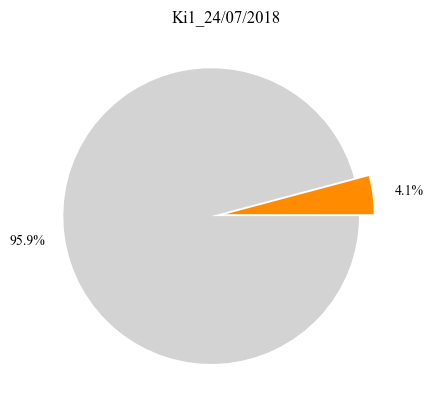

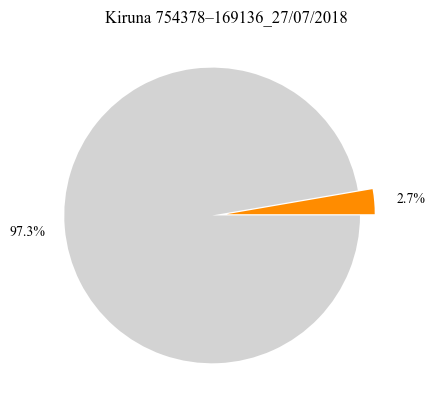

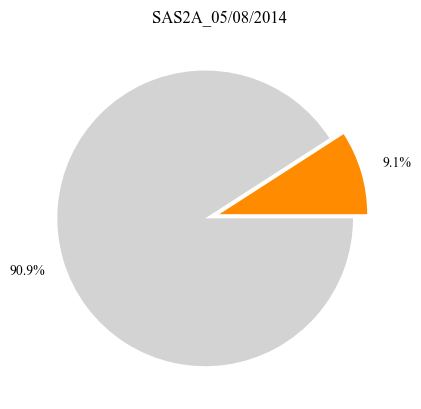

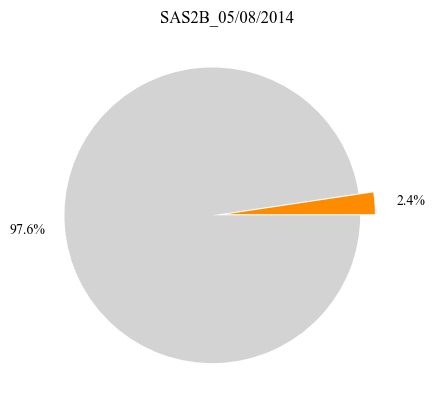

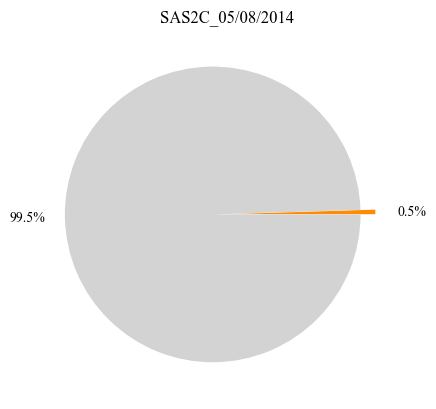

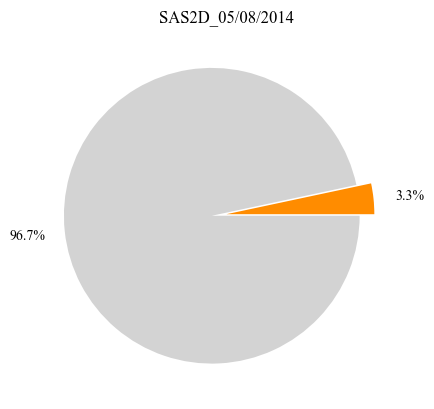

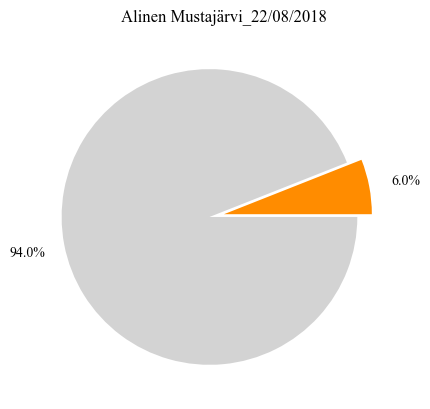

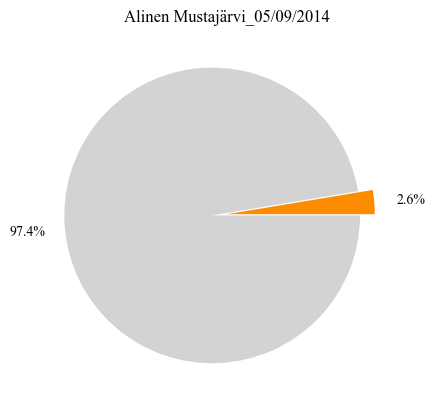

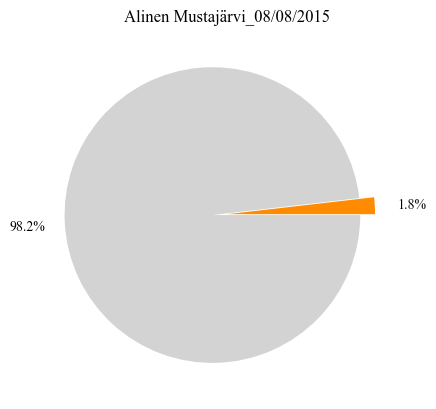

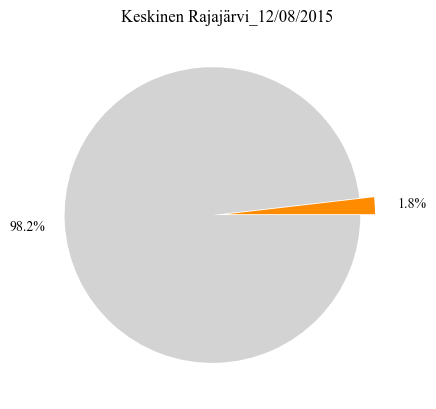

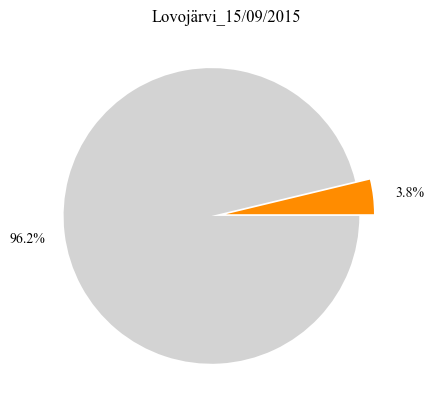

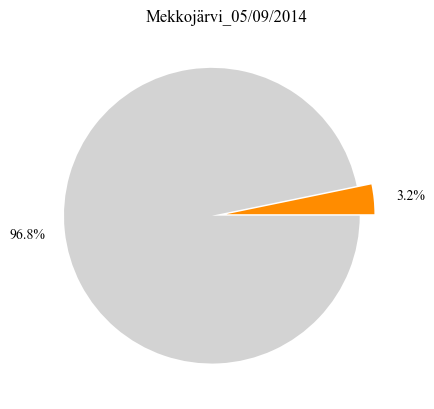

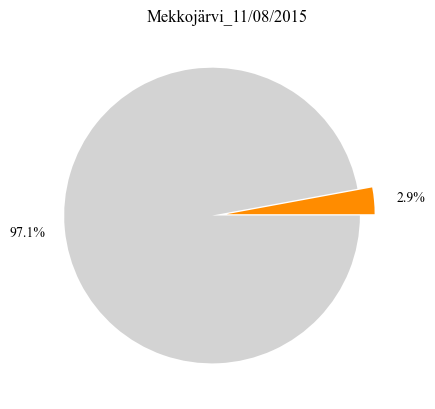

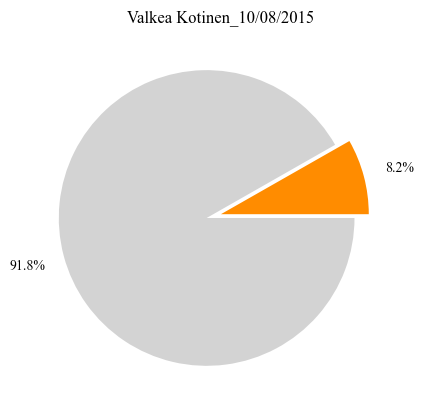

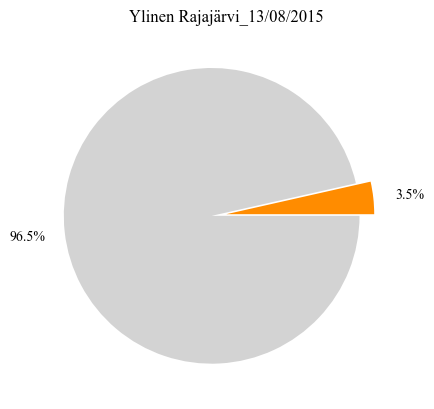

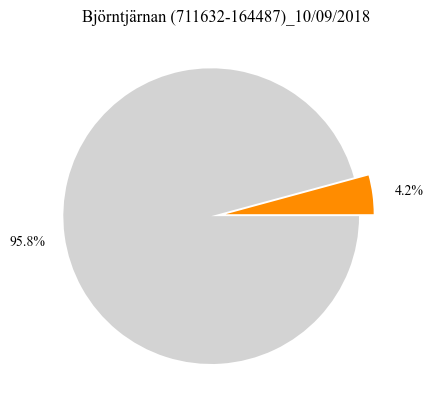

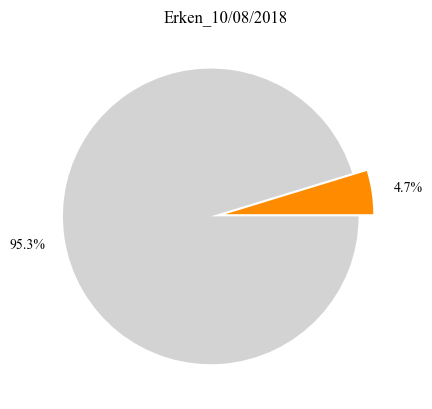

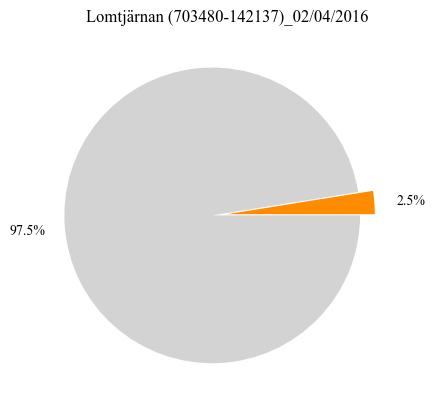

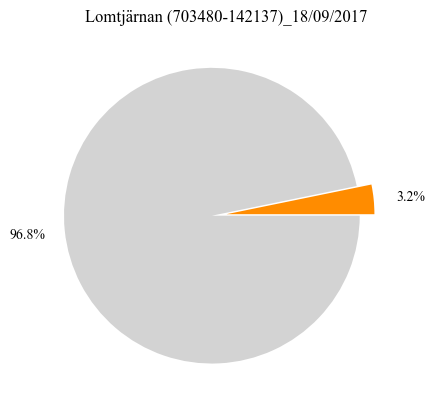

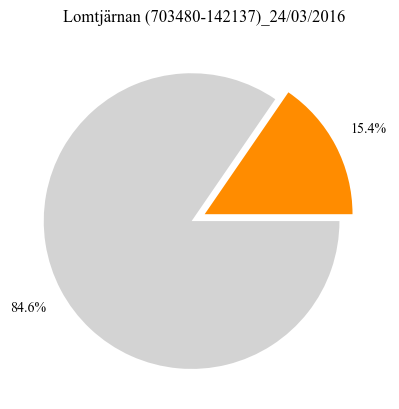

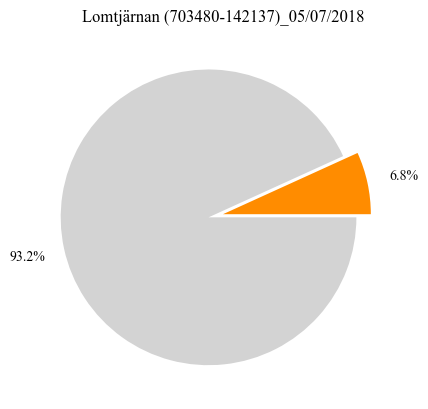

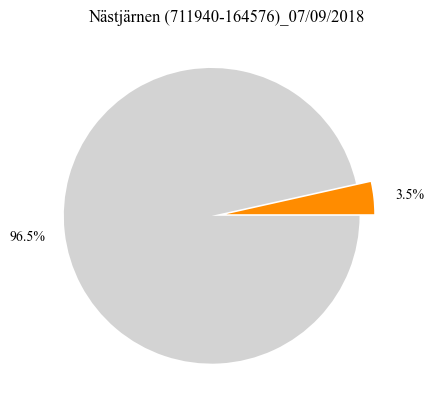

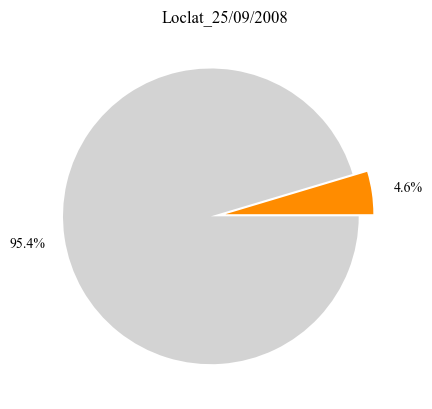

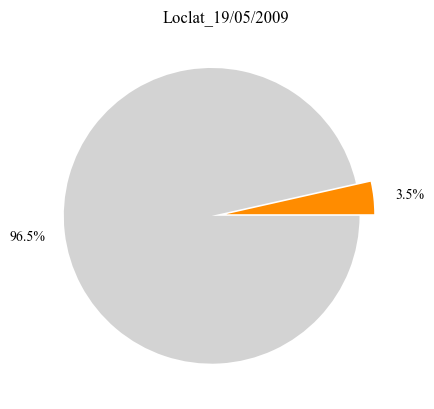

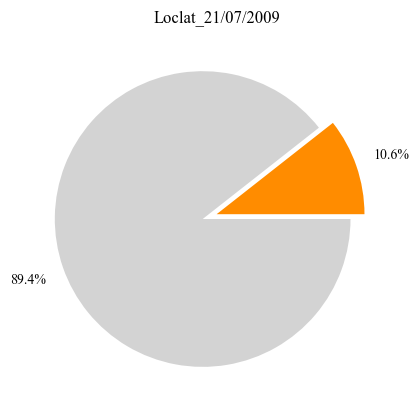

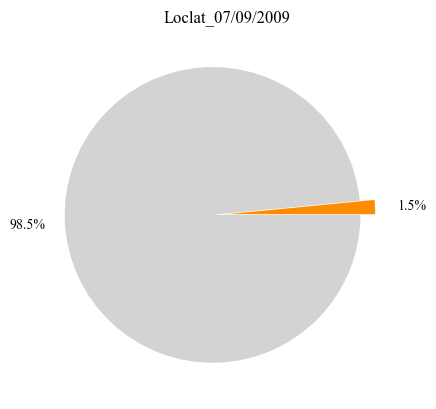

In [33]:
for i,j in zip(lake_time_group,optimal_niche_abd):
    piechart(i,j)

In [34]:
# export the MTB community distribution across lake_time groups table
MTB_cdabd_df = pd.DataFrame(data={'Lake_time': lake_time_group, 'Number_of_sampling_sites': number_of_samples, 
                   'Number_of_MTB_existing_sampling_sites':number_of_mtb_existing_samples,
                  'Optimal_niche_abandance_of_MTB (%)':optimal_niche_abd})
MTB_cdabd_df
# MTB_cdabd_df.to_excel('Tables/TableS8_MTB_community_distribution_abundance_across_26_lake_time_groups.xlsx',index=None)

,Lake_time,Number_of_sampling_sites,Number_of_MTB_existing_sampling_sites,Optimal_niche_abandance_of_MTB (%)
0,Ki1_24/07/2018,8,6,4.144649
1,Kiruna 754378–169136_27/07/2018,5,3,2.713493
2,SAS2A_05/08/2014,29,13,9.107922
3,SAS2B_05/08/2014,4,3,2.359353
4,SAS2C_05/08/2014,11,2,0.493528
5,SAS2D_05/08/2014,5,2,3.342407
6,Alinen Mustajärvi_22/08/2018,4,2,5.995199
7,Alinen Mustajärvi_05/09/2014,4,2,2.619769
8,Alinen Mustajärvi_08/08/2015,6,4,1.831534
9,Keskinen Rajajärvi_12/08/2015,7,4,1.839143


In [35]:
# describe the min, max, median of MTB community abundance across lakes
import statistics
median = statistics.median(optimal_niche_abd)
mini = min(optimal_niche_abd)
maxi = max(optimal_niche_abd)
print(median, mini, maxi)

3.5100663930874996 0.49352785481913775 15.422338750651221


### 4. Profile the distribution and abundance of MTB belonging to different phyla

#### 4.1 Count the phyla of new assembled MTB MAGs

In [36]:
tmp = MTB_bin_feature_df.phylum.value_counts().sort_index().reset_index()

In [37]:
custom_dict = {'p__Desulfobacterota': 0, 
               'p__Desulfobacterota_I': 1,
               'p__Desulfobacterota_G': 2, 
               'p__Bdellovibrionota': 3, 
               'p__Myxococcota': 4,
               'p__Proteobacteria;c__Alphaproteobacteria':5,
               'p__Proteobacteria;c__Gammaproteobacteria':6,
               'p__Proteobacteria;c__Magnetococcia':7}
tmp.sort_values(by=['phylum'], key=lambda x: x.map(custom_dict),inplace=True)
tmp

,phylum,count
1,p__Desulfobacterota,29
3,p__Desulfobacterota_I,4
2,p__Desulfobacterota_G,1
0,p__Bdellovibrionota,7
5,p__Myxococcota,1
7,p__Proteobacteria;c__Alphaproteobacteria,12
8,p__Proteobacteria;c__Gammaproteobacteria,2
9,p__Proteobacteria;c__Magnetococcia,1
4,p__Hydrogenedentota,1
6,p__Omnitrophota,5


In [38]:
colors_dict = {'p__Desulfobacterota':'#1565c0ff',
'p__Omnitrophota':'#f44336ff',
'p__Hydrogenedentota':'#ffc107ff',
'p__Desulfobacterota_I':'#8bc34aff',
'p__Desulfobacterota_G':'#009688ff',
'p__Proteobacteria;c__Magnetococcia':'#b52dc8ff',
'p__Proteobacteria;c__Gammaproteobacteria':'#f17363ff',
'p__Proteobacteria;c__Alphaproteobacteria':'#ad1457ff',
'p__Myxococcota':'#ff9800ff',
'p__Bdellovibrionota':'#448affff'
}

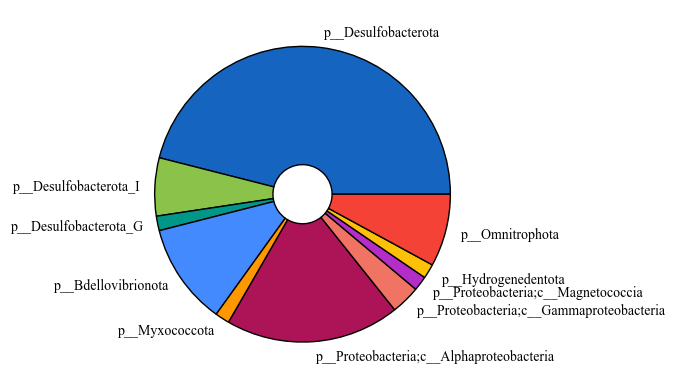

In [39]:
fig1, ax1 = plt.subplots()
counts=tmp['count'].tolist()
labels=tmp.phylum.tolist()
colors=[colors_dict[i] for i in labels]
ax1.pie(counts, radius=1,labels=labels, colors=colors,
       wedgeprops=dict(width=0.8, edgecolor='black'))

plt.show()
# ax1.get_figure().savefig('Fig3_phyla_counts.svg', bbox_inches='tight')

#### 4.2 MTB MAGs quality counts

In [40]:
tmp = MTB_bin_feature_df.Quality.value_counts().reset_index()

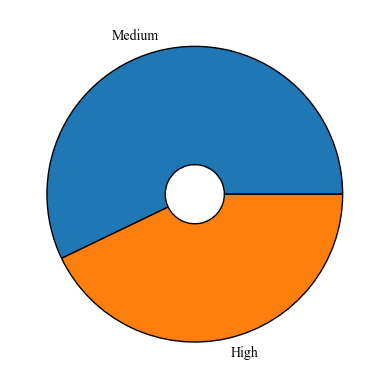

In [41]:
fig1, ax1 = plt.subplots()
counts=tmp['count'].tolist()
labels=tmp.Quality.tolist()
ax1.pie(counts, radius=1,labels=labels, 
       wedgeprops=dict(width=0.8, edgecolor='black'))

plt.show()
# ax1.get_figure().savefig('Fig2_MAG_quality_counts.svg', bbox_inches='tight')

#### 4.3 Describe the distribution and abundance of MTB belonging to different phyla

##### 4.3.1 Organize the distribution and abundance table of MTB

In [42]:
MTB_distr_abd_df = pd.DataFrame(data={'detection': detec_df.stack(), 'q2q3_mean_coverage':q2q3_mc_df.stack()}).reset_index().rename(columns={'level_0':'sample_id','level_1':'bins'})
MTB_distr_abd_df.set_index('sample_id',inplace=True)
MTB_distr_abd_df

,bins,detection,q2q3_mean_coverage
sample_id,,,
A1,SFLP_MTB_A4_bin1,0.023354,0.001347
A1,SFLP_MTB_A4_bin21,0.039823,0.0
A1,SFLP_MTB_AM5_bin22,0.022037,0.005208
A1,SFLP_MTB_AM-2014-D3_bin8,0.00702,0.000005
A1,SFLP_MTB_AM-2014-D4_bin6,0.019819,0.0
...,...,...,...
YR4,SFLP_MTB_Umea3p3_bin40,0.113941,0.009577
YR4,SFLP_MTB_Umea3p4_bin52,0.001762,0.0
YR4,SFLP_MTB_VK2_bin2,0.060399,0.100707


In [43]:
MTB_distr_abd_df['Sampling_depth'] = meta_df['geographic location (depth)']
MTB_distr_abd_df['site name'] = meta_df['site name']
MTB_distr_abd_df['collection date'] = meta_df['collection date']
MTB_distr_abd_df['scaling_factor'] = rc_df.scaling_factor
MTB_distr_abd_df['lake_time_group'] = MTB_distr_abd_df['site name']+'_'+MTB_distr_abd_df['collection date']
MTB_distr_abd_df

,bins,detection,q2q3_mean_coverage,Sampling_depth,site name,collection date,scaling_factor,lake_time_group
sample_id,,,,,,,,
A1,SFLP_MTB_A4_bin1,0.023354,0.001347,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014
A1,SFLP_MTB_A4_bin21,0.039823,0.0,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014
A1,SFLP_MTB_AM5_bin22,0.022037,0.005208,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014
A1,SFLP_MTB_AM-2014-D3_bin8,0.00702,0.000005,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014
A1,SFLP_MTB_AM-2014-D4_bin6,0.019819,0.0,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014
...,...,...,...,...,...,...,...,...
YR4,SFLP_MTB_Umea3p3_bin40,0.113941,0.009577,5.00,Ylinen Rajajärvi,13/08/2015,1.502135,Ylinen Rajajärvi_13/08/2015
YR4,SFLP_MTB_Umea3p4_bin52,0.001762,0.0,5.00,Ylinen Rajajärvi,13/08/2015,1.502135,Ylinen Rajajärvi_13/08/2015
YR4,SFLP_MTB_VK2_bin2,0.060399,0.100707,5.00,Ylinen Rajajärvi,13/08/2015,1.502135,Ylinen Rajajärvi_13/08/2015


In [44]:
MTB_distr_abd_df = MTB_distr_abd_df.reset_index().set_index('bins')
MTB_distr_abd_df['phylum'] = MTB_bin_feature_df.set_index('MTB MAG').phylum
MTB_distr_abd_df = MTB_distr_abd_df.reset_index().set_index('sample_id')
MTB_distr_abd_df

,bins,detection,q2q3_mean_coverage,Sampling_depth,site name,collection date,scaling_factor,lake_time_group,phylum
sample_id,,,,,,,,,
A1,SFLP_MTB_A4_bin1,0.023354,0.001347,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014,p__Desulfobacterota
A1,SFLP_MTB_A4_bin21,0.039823,0.0,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014,p__Desulfobacterota
A1,SFLP_MTB_AM5_bin22,0.022037,0.005208,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014,p__Omnitrophota
A1,SFLP_MTB_AM-2014-D3_bin8,0.00702,0.000005,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014,p__Proteobacteria;c__Alphaproteobacteria
A1,SFLP_MTB_AM-2014-D4_bin6,0.019819,0.0,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014,p__Proteobacteria;c__Alphaproteobacteria
...,...,...,...,...,...,...,...,...,...
YR4,SFLP_MTB_Umea3p3_bin40,0.113941,0.009577,5.00,Ylinen Rajajärvi,13/08/2015,1.502135,Ylinen Rajajärvi_13/08/2015,p__Proteobacteria;c__Alphaproteobacteria
YR4,SFLP_MTB_Umea3p4_bin52,0.001762,0.0,5.00,Ylinen Rajajärvi,13/08/2015,1.502135,Ylinen Rajajärvi_13/08/2015,p__Proteobacteria;c__Magnetococcia
YR4,SFLP_MTB_VK2_bin2,0.060399,0.100707,5.00,Ylinen Rajajärvi,13/08/2015,1.502135,Ylinen Rajajärvi_13/08/2015,p__Proteobacteria;c__Alphaproteobacteria


In [45]:
delta=['p__Desulfobacterota','p__Desulfobacterota_I','p__Desulfobacterota_G','p__Bdellovibrionota','p__Myxococcota']
MTB_distr_abd_df['taxa'] = MTB_distr_abd_df.phylum.apply(lambda x: 'Deltaproteobacteria' if x in delta else ('Alphaproteobacteria' if 'Alpha' in x else x))
MTB_distr_abd_df

,bins,detection,q2q3_mean_coverage,Sampling_depth,site name,collection date,scaling_factor,lake_time_group,phylum,taxa
sample_id,,,,,,,,,,
A1,SFLP_MTB_A4_bin1,0.023354,0.001347,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014,p__Desulfobacterota,Deltaproteobacteria
A1,SFLP_MTB_A4_bin21,0.039823,0.0,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014,p__Desulfobacterota,Deltaproteobacteria
A1,SFLP_MTB_AM5_bin22,0.022037,0.005208,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014,p__Omnitrophota,p__Omnitrophota
A1,SFLP_MTB_AM-2014-D3_bin8,0.00702,0.000005,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014,p__Proteobacteria;c__Alphaproteobacteria,Alphaproteobacteria
A1,SFLP_MTB_AM-2014-D4_bin6,0.019819,0.0,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014,p__Proteobacteria;c__Alphaproteobacteria,Alphaproteobacteria
...,...,...,...,...,...,...,...,...,...,...
YR4,SFLP_MTB_Umea3p3_bin40,0.113941,0.009577,5.00,Ylinen Rajajärvi,13/08/2015,1.502135,Ylinen Rajajärvi_13/08/2015,p__Proteobacteria;c__Alphaproteobacteria,Alphaproteobacteria
YR4,SFLP_MTB_Umea3p4_bin52,0.001762,0.0,5.00,Ylinen Rajajärvi,13/08/2015,1.502135,Ylinen Rajajärvi_13/08/2015,p__Proteobacteria;c__Magnetococcia,p__Proteobacteria;c__Magnetococcia
YR4,SFLP_MTB_VK2_bin2,0.060399,0.100707,5.00,Ylinen Rajajärvi,13/08/2015,1.502135,Ylinen Rajajärvi_13/08/2015,p__Proteobacteria;c__Alphaproteobacteria,Alphaproteobacteria


In [46]:
# set abundance(q2q3 mean coverage) value to 0 if detection<0.25
# scaling abundance value by scaling_factor
MTB_distr_abd_df['abundance'] = MTB_distr_abd_df.apply(lambda x: x.q2q3_mean_coverage*x.scaling_factor if x.detection>=0.25 else 0, axis=1)
MTB_distr_abd_df

,bins,detection,q2q3_mean_coverage,Sampling_depth,site name,collection date,scaling_factor,lake_time_group,phylum,taxa,abundance
sample_id,,,,,,,,,,,
A1,SFLP_MTB_A4_bin1,0.023354,0.001347,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014,p__Desulfobacterota,Deltaproteobacteria,0.000000
A1,SFLP_MTB_A4_bin21,0.039823,0.0,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014,p__Desulfobacterota,Deltaproteobacteria,0.000000
A1,SFLP_MTB_AM5_bin22,0.022037,0.005208,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014,p__Omnitrophota,p__Omnitrophota,0.000000
A1,SFLP_MTB_AM-2014-D3_bin8,0.00702,0.000005,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014,p__Proteobacteria;c__Alphaproteobacteria,Alphaproteobacteria,0.000000
A1,SFLP_MTB_AM-2014-D4_bin6,0.019819,0.0,0.55,SAS2A,05/08/2014,1.069728,SAS2A_05/08/2014,p__Proteobacteria;c__Alphaproteobacteria,Alphaproteobacteria,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
YR4,SFLP_MTB_Umea3p3_bin40,0.113941,0.009577,5.00,Ylinen Rajajärvi,13/08/2015,1.502135,Ylinen Rajajärvi_13/08/2015,p__Proteobacteria;c__Alphaproteobacteria,Alphaproteobacteria,0.000000
YR4,SFLP_MTB_Umea3p4_bin52,0.001762,0.0,5.00,Ylinen Rajajärvi,13/08/2015,1.502135,Ylinen Rajajärvi_13/08/2015,p__Proteobacteria;c__Magnetococcia,p__Proteobacteria;c__Magnetococcia,0.000000
YR4,SFLP_MTB_VK2_bin2,0.060399,0.100707,5.00,Ylinen Rajajärvi,13/08/2015,1.502135,Ylinen Rajajärvi_13/08/2015,p__Proteobacteria;c__Alphaproteobacteria,Alphaproteobacteria,0.000000


In [47]:
MTB_distr_abd_df = MTB_distr_abd_df.loc[:,['lake_time_group','Sampling_depth','taxa','abundance']].copy()

In [48]:
MTB_distr_abd_df = MTB_distr_abd_df[MTB_distr_abd_df.lake_time_group.apply(lambda x: True if x in lake_time_group else False)]
MTB_distr_abd_df

,lake_time_group,Sampling_depth,taxa,abundance
sample_id,,,,
A1,SAS2A_05/08/2014,0.55,Deltaproteobacteria,0.000000
A1,SAS2A_05/08/2014,0.55,Deltaproteobacteria,0.000000
A1,SAS2A_05/08/2014,0.55,p__Omnitrophota,0.000000
A1,SAS2A_05/08/2014,0.55,Alphaproteobacteria,0.000000
A1,SAS2A_05/08/2014,0.55,Alphaproteobacteria,0.000000
...,...,...,...,...
YR4,Ylinen Rajajärvi_13/08/2015,5.00,Alphaproteobacteria,0.000000
YR4,Ylinen Rajajärvi_13/08/2015,5.00,p__Proteobacteria;c__Magnetococcia,0.000000
YR4,Ylinen Rajajärvi_13/08/2015,5.00,Alphaproteobacteria,0.000000


In [49]:
MTB_distr_abd_df.reset_index(inplace=True)
MTB_distr_abd_df = MTB_distr_abd_df.groupby(['sample_id','lake_time_group','Sampling_depth','taxa']).sum().reset_index()
MTB_distr_abd_df

,sample_id,lake_time_group,Sampling_depth,taxa,abundance
0,A1,SAS2A_05/08/2014,0.55,Alphaproteobacteria,0.000000
1,A1,SAS2A_05/08/2014,0.55,Deltaproteobacteria,0.000000
2,A1,SAS2A_05/08/2014,0.55,p__Hydrogenedentota,0.000000
3,A1,SAS2A_05/08/2014,0.55,p__Omnitrophota,0.000000
4,A1,SAS2A_05/08/2014,0.55,p__Proteobacteria;c__Gammaproteobacteria,0.000000
...,...,...,...,...,...
985,YR4,Ylinen Rajajärvi_13/08/2015,5.00,Deltaproteobacteria,3.883793
986,YR4,Ylinen Rajajärvi_13/08/2015,5.00,p__Hydrogenedentota,0.000000
987,YR4,Ylinen Rajajärvi_13/08/2015,5.00,p__Omnitrophota,0.000000
988,YR4,Ylinen Rajajärvi_13/08/2015,5.00,p__Proteobacteria;c__Gammaproteobacteria,0.000000


In [50]:
# MTB_distr_abd_df.to_excel('Tables/TableS9_distribution_and_abundance_profile_of_MTB_belonging_to_different_taxa_across_26_lake_time_groups.xlsx', index=None)

##### 4.3.2 Describe the distribution and abundance of MTB belonging to different phyla

In [51]:
MTB_distr_abd_df

,sample_id,lake_time_group,Sampling_depth,taxa,abundance
0,A1,SAS2A_05/08/2014,0.55,Alphaproteobacteria,0.000000
1,A1,SAS2A_05/08/2014,0.55,Deltaproteobacteria,0.000000
2,A1,SAS2A_05/08/2014,0.55,p__Hydrogenedentota,0.000000
3,A1,SAS2A_05/08/2014,0.55,p__Omnitrophota,0.000000
4,A1,SAS2A_05/08/2014,0.55,p__Proteobacteria;c__Gammaproteobacteria,0.000000
...,...,...,...,...,...
985,YR4,Ylinen Rajajärvi_13/08/2015,5.00,Deltaproteobacteria,3.883793
986,YR4,Ylinen Rajajärvi_13/08/2015,5.00,p__Hydrogenedentota,0.000000
987,YR4,Ylinen Rajajärvi_13/08/2015,5.00,p__Omnitrophota,0.000000
988,YR4,Ylinen Rajajärvi_13/08/2015,5.00,p__Proteobacteria;c__Gammaproteobacteria,0.000000


In [52]:
for n,dftmp in MTB_distr_abd_df.groupby('taxa'):
    num_of_samples=len(dftmp[dftmp.abundance>0])
    print(f'MTB belonging to {n} exist in {num_of_samples} samples across 26 lake-time-groups')

MTB belonging to Alphaproteobacteria exist in 38 samples across 26 lake-time-groups
MTB belonging to Deltaproteobacteria exist in 76 samples across 26 lake-time-groups
MTB belonging to p__Hydrogenedentota exist in 7 samples across 26 lake-time-groups
MTB belonging to p__Omnitrophota exist in 36 samples across 26 lake-time-groups
MTB belonging to p__Proteobacteria;c__Gammaproteobacteria exist in 5 samples across 26 lake-time-groups
MTB belonging to p__Proteobacteria;c__Magnetococcia exist in 2 samples across 26 lake-time-groups


/tmp/ipykernel_1497/1545882630.py:2: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=tmp, x="taxa", y="abundance",


Text(0, 0.5, 'Abundance')

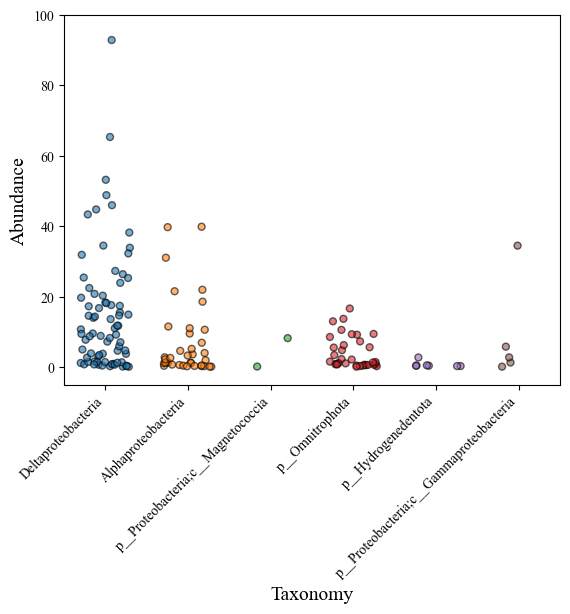

In [53]:
tmp=MTB_distr_abd_df[MTB_distr_abd_df.abundance>0].copy()
sns.stripplot(data=tmp, x="taxa", y="abundance",
              order=['Deltaproteobacteria', 'Alphaproteobacteria', 'p__Proteobacteria;c__Magnetococcia', 
                     'p__Omnitrophota','p__Hydrogenedentota', 'p__Proteobacteria;c__Gammaproteobacteria'],
              palette='tab10',
              alpha=0.6, jitter=0.3, edgecolor='black', linewidth=1)#color='dodgerblue',
plt.ylim(-5,100)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Taxonomy', fontsize=14)
plt.ylabel('Abundance', fontsize=14)
# plt.savefig('Abundance_of_MTB_belonging_to_different_taxa_across_26_lake-time-groups.svg', bbox_inches='tight')

##### 4.3.4 Test the significant difference between the abundance values between Alpha- and Delta-proteobacteria MTB across 26 lake-time groups

In [54]:
tmp=MTB_distr_abd_df[MTB_distr_abd_df.abundance>0].copy()
tmp

,sample_id,lake_time_group,Sampling_depth,taxa,abundance
6,A2,SAS2A_05/08/2014,0.95,Alphaproteobacteria,0.357923
7,A2,SAS2A_05/08/2014,0.95,Deltaproteobacteria,1.160379
12,A3,SAS2A_05/08/2014,1.35,Alphaproteobacteria,1.237281
13,A3,SAS2A_05/08/2014,1.35,Deltaproteobacteria,18.362638
19,A4,SAS2A_05/08/2014,2.25,Deltaproteobacteria,65.358636
...,...,...,...,...,...
960,VK4,Valkea Kotinen_10/08/2015,4.50,Alphaproteobacteria,0.232773
972,YR2,Ylinen Rajajärvi_13/08/2015,1.50,Alphaproteobacteria,0.703150
979,YR3,Ylinen Rajajärvi_13/08/2015,4.00,Deltaproteobacteria,0.312398
984,YR4,Ylinen Rajajärvi_13/08/2015,5.00,Alphaproteobacteria,2.602394


In [55]:
a_df=tmp[tmp.taxa=='Alphaproteobacteria']
a_abd=a_df[a_df.abundance>0].abundance.tolist()
b_df=tmp[tmp.taxa=='Deltaproteobacteria']
b_abd=b_df[b_df.abundance>0].abundance.tolist()

In [56]:
# alphaproteobacteria abundance data is not normally distributed
stats.normaltest(a_abd)

NormaltestResult(statistic=61.975889789104684, pvalue=3.484227681174376e-14)

In [57]:
# deltaproteobacteria abundance data is not normally distributed, either.
stats.normaltest(b_abd)

NormaltestResult(statistic=44.31028927253996, pvalue=2.388597309048435e-10)

In [58]:
# delta-, alphaproteobacteria MTB abundance have significant difference.
U,p=stats.mannwhitneyu(a_abd,b_abd)
print('The probobility to wrongly reject the null hypothesis is {:g}'.format(p))

The probobility to wrongly reject the null hypothesis is 0.00358772


##### 4.3.3 Plot the distribution and abundance bubble figure of different phyla in lake_time_groups

In [59]:
def draw_plot(n, df_tmp):
    color_scale = alt.Scale(domain=['Alphaproteobacteria', 'Deltaproteobacteria','p__Hydrogenedentota','p__Omnitrophota','p__Proteobacteria;c__Gammaproteobacteria','p__Proteobacteria;c__Magnetococcia'],
                        range=['#ad1457ff', 'darkblue','#ffc107ff','#f44336ff','#f17363ff','#b52dc8ff'])
    
    chart = alt.Chart(df_tmp).mark_circle(
        opacity=0.7,
        stroke='black',
        strokeWidth=1,
    ).encode(
        alt.X('taxa:O', title='Taxa'),
        alt.Y('Sampling_depth:O',title='Depth (m)'),
        alt.Size('abundance:Q',scale=alt.Scale(range=[10, 1500]), title='Abundance'),
        alt.Color('taxa:O', scale=color_scale, legend=None),
    ).properties(
        width=100,
        height=300,
        title=n
    )
    return chart

In [60]:
group_phyla_dfs = {}
for n,dftmp in MTB_distr_abd_df.groupby('lake_time_group'):
    group_phyla_dfs[n]=dftmp

In [61]:
for i in group_phyla_dfs:
    print(i)
    chart = draw_plot(i, group_phyla_dfs[i])
    chart.display()

Alinen Mustajärvi_05/09/2014


alt.Chart(...)

Alinen Mustajärvi_08/08/2015


alt.Chart(...)

Alinen Mustajärvi_22/08/2018


...

alt.Chart(...)

Valkea Kotinen_10/08/2015


alt.Chart(...)

Ylinen Rajajärvi_13/08/2015


alt.Chart(...)

In [62]:
alpha_delta_MTB_distr_abd_df = MTB_distr_abd_df.loc[(MTB_distr_abd_df.taxa=='Alphaproteobacteria') | (MTB_distr_abd_df.taxa=='Deltaproteobacteria')]

In [63]:
alpha_delta_MTB_distr_abd_df['lake_time_phyla'] = alpha_delta_MTB_distr_abd_df.apply(lambda x: x.lake_time_group+'_α' if x.taxa == 'Alphaproteobacteria' else x.lake_time_group+'_δ', axis=1)

/tmp/ipykernel_1497/56659805.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alpha_delta_MTB_distr_abd_df['lake_time_phyla'] = alpha_delta_MTB_distr_abd_df.apply(lambda x: x.lake_time_group+'_α' if x.taxa == 'Alphaproteobacteria' else x.lake_time_group+'_δ', axis=1)


In [64]:
color_scale = alt.Scale(domain=['Alphaproteobacteria', 'Deltaproteobacteria'],range=['#ad1457ff', 'darkblue',])

alt.Chart(alpha_delta_MTB_distr_abd_df).mark_circle(
    opacity=0.7,
    stroke='black',
    strokeWidth=0.5,
    # color='darkblue'
).encode(
    alt.X('lake_time_phyla:O'),
    alt.Y('Sampling_depth:O',title='Depth (m)'),
    alt.Size('abundance:Q',
             scale=alt.Scale(range=[1, 4000])),
    alt.Color('taxa:O', scale=color_scale,)
).properties(
    width=850,
    height=250)

alt.Chart(...)

### 5. Describe the vertical distribution of MTB community

#### 5.1 Profile MTB community abundance in different oxic zone and test if there are significant differences of MTB abundance among oxygen zones

In [65]:
rc_df

,total_reads,recruited_reads,scaling_factor,site name,collection date,MTB existence,MTB_community_abundance,lake_time
sample_id,,,,,,,,
A1,33370665,40886,1.069728,SAS2A,05/08/2014,False,0.122521,SAS2A_05/08/2014
A2,60228797,242769,0.592699,SAS2A,05/08/2014,True,0.403078,SAS2A_05/08/2014
A3,43085200,993442,0.828534,SAS2A,05/08/2014,True,2.305762,SAS2A_05/08/2014
A4,42701992,2902414,0.835969,SAS2A,05/08/2014,True,6.796905,SAS2A_05/08/2014
A5,35519910,57611,1.005001,B1-2,05/08/2014,False,0.162194,B1-2_05/08/2014
...,...,...,...,...,...,...,...,...
VK4,30076610,141728,1.186887,Valkea Kotinen,10/08/2015,True,0.471223,Valkea Kotinen_10/08/2015
YR1,28787255,29290,1.240046,Ylinen Rajajärvi,13/08/2015,False,0.101746,Ylinen Rajajärvi_13/08/2015
YR2,33737891,194525,1.058084,Ylinen Rajajärvi,13/08/2015,True,0.576577,Ylinen Rajajärvi_13/08/2015


In [66]:
oxygen_series=meta_df.oxygen
mtb_existence_series=meta_df['MTB existence']
mtb_abd_series=rc_df['MTB_community_abundance']
MTB_distri_across_oxygen_zones_df = pd.DataFrame(data={'Oxygen': oxygen_series,'MTB_existence': mtb_existence_series,'MTB_community_abundance': mtb_abd_series})
MTB_distri_across_oxygen_zones_df = MTB_distri_across_oxygen_zones_df[MTB_distri_across_oxygen_zones_df.MTB_existence==True]
MTB_distri_across_oxygen_zones_df

,Oxygen,MTB_existence,MTB_community_abundance
sample_id,,,
A2,0.33,True,0.403078
A3,0.29,True,2.305762
A4,0.35,True,6.796905
AM-2014-D3,0.48,True,2.337942
AM-2014-D4,0.52,True,4.144649
...,...,...,...
VK3,0.46,True,3.096729
VK4,0.49,True,0.471223
YR2,0.42,True,0.576577


In [67]:
MTB_distri_across_oxygen_zones_df = MTB_distri_across_oxygen_zones_df.dropna(subset='Oxygen').copy()
MTB_distri_across_oxygen_zones_df['oxic_zone'] = MTB_distri_across_oxygen_zones_df.Oxygen.apply(lambda x: 'oxic' if x >=2 else ('hypoxic' if x>=0.5 else 'anoxic'))
MTB_distri_across_oxygen_zones_df

,Oxygen,MTB_existence,MTB_community_abundance,oxic_zone
sample_id,,,,
A2,0.33,True,0.403078,anoxic
A3,0.29,True,2.305762,anoxic
A4,0.35,True,6.796905,anoxic
AM-2014-D3,0.48,True,2.337942,anoxic
AM-2014-D4,0.52,True,4.144649,hypoxic
...,...,...,...,...
VK3,0.46,True,3.096729,anoxic
VK4,0.49,True,0.471223,anoxic
YR2,0.42,True,0.576577,anoxic


Text(0, 0.5, 'MTB community abundance (%)')

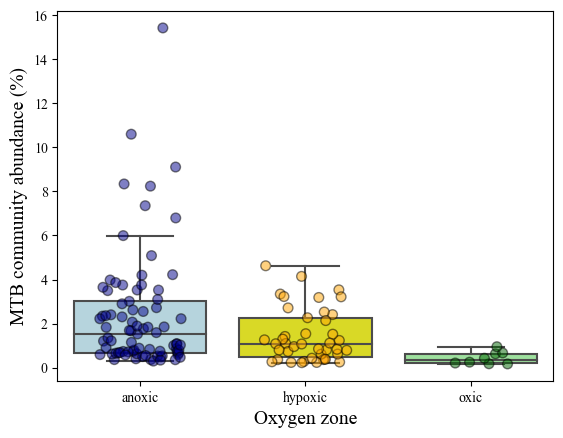

In [68]:
ax = sns.boxplot(data=MTB_distri_across_oxygen_zones_df,x="oxic_zone",y="MTB_community_abundance", hue='oxic_zone',fliersize=0,
                 palette={"anoxic": "lightblue", "hypoxic": "yellow", 'oxic':'lightgreen'},
                 dodge=False, saturation=0.7
                )#showmeans=True, meanline=True
ax = sns.stripplot(data=MTB_distri_across_oxygen_zones_df,x="oxic_zone",y="MTB_community_abundance",alpha=0.5,hue='oxic_zone',
                   edgecolor="black", linewidth=1,
                   palette={"anoxic": "darkblue", "hypoxic": "orange", 'oxic':'darkgreen'},
                   size=7,jitter=0.25
                )# ,
ax.get_legend().remove()
plt.xlabel('Oxygen zone', fontsize=14)
plt.ylabel('MTB community abundance (%)', fontsize=14)
# plt.savefig('MTB_community_abundance_against_oxygen_zones_boxplot.svg',bbox_inches='tight')

In [69]:
for n, dftmp in MTB_distri_across_oxygen_zones_df.groupby('oxic_zone'):
    num_of_samples=len(dftmp)
    print(f'The number of {n} samples that contain MTB is: {num_of_samples}')

The number of anoxic samples that contain MTB is: 81
The number of hypoxic samples that contain MTB is: 42
The number of oxic samples that contain MTB is: 8


In [70]:
# significant difference analysis of MTB community abundance among different oxygen zones
oxic_MTB_abds = MTB_distri_across_oxygen_zones_df[MTB_distri_across_oxygen_zones_df.oxic_zone=='oxic'].MTB_community_abundance.tolist()
hypoxic_MTB_abds = MTB_distri_across_oxygen_zones_df[MTB_distri_across_oxygen_zones_df.oxic_zone=='hypoxic'].MTB_community_abundance.tolist()
anoxic_MTB_abds = MTB_distri_across_oxygen_zones_df[MTB_distri_across_oxygen_zones_df.oxic_zone=='anoxic'].MTB_community_abundance.tolist()
print(len(oxic_MTB_abds), len(hypoxic_MTB_abds), len(anoxic_MTB_abds))

# stats.normaltest(a_abd)

8 42 81


In [71]:
# MTB abundance data of different oxygen zones are not normally distributed
s0,p0 = stats.normaltest(oxic_MTB_abds)
s1,p1 = stats.normaltest(hypoxic_MTB_abds)
s2,p2 = stats.normaltest(anoxic_MTB_abds)
print(p0, p1, p2)

0.5308930461355901 0.021788794060949183 4.5007412750125356e-14


/root/miniconda3/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [72]:
# employ mannwhitneyu to test the difference of MTB abundaces among different oxygen zone
U01,p01=stats.mannwhitneyu(oxic_MTB_abds,hypoxic_MTB_abds)
U02,p02=stats.mannwhitneyu(oxic_MTB_abds,anoxic_MTB_abds)
U12,p12=stats.mannwhitneyu(hypoxic_MTB_abds,anoxic_MTB_abds)

print(p01,p02,p12, sep='\n')

0.002465290806404762
8.07756683160663e-05
0.06694268650860852


#### 5.2 Abundance profile of all MTB MAGs across all samples

##### 5.2.1 Arrange the MTB MAGs' abundance table across all samples

In [73]:
custom_order = pd.Series(['p__Desulfobacterota','p__Desulfobacterota_I',
                                    'p__Desulfobacterota_G','p__Bdellovibrionota',
                                    'p__Myxococcota','p__Proteobacteria;c__Alphaproteobacteria',
                                    'p__Proteobacteria;c__Magnetococcia',
                                    'p__Proteobacteria;c__Gammaproteobacteria','p__Omnitrophota',
                                    'p__Hydrogenedentota']).reset_index().set_index(0)['index'].to_dict()

In [74]:
# set the q2q3 mean coverage value to NaN if the detection value <=0.25
MTB_abd_lineage_df = q2q3_mc_df[detec_df>=0.25].fillna(np.nan)

# use scaling factor to scale the q2q3 mean coverage to eliminate the influence of sequencing depth
scaling_factor_dict = rc_df.scaling_factor.to_dict()
MTB_abd_lineage_df = MTB_abd_lineage_df.apply(lambda x: x*scaling_factor_dict[x.name], axis=1)

# drop the sample without MTB and sample without OD record
MTB_abd_lineage_df = MTB_abd_lineage_df[(MTB_abd_lineage_df>0).any(axis=1)]
MTB_abd_lineage_df['oxygen']=meta_df.oxygen
MTB_abd_lineage_df = MTB_abd_lineage_df.loc[MTB_abd_lineage_df.oxygen.dropna().index,:].copy()

# drop the MTB MAG that doesn't exist in any of the remainning samples
MTB_abd_lineage_df = MTB_abd_lineage_df.loc[:,MTB_abd_lineage_df.notna().any()]

# sort the sample according to the DO vlue
MTB_abd_lineage_df.sort_values('oxygen',inplace=True)

# sort the MTB MAG accorrding to the taxonomy
MTB_abd_lineage_df=MTB_abd_lineage_df.iloc[:,:-1].T
MTB_abd_lineage_df['phylum'] = MTB_bin_feature_df.set_index('MTB MAG').phylum
MTB_abd_lineage_df.sort_values(by='phylum', key=lambda x: x.map(custom_order),inplace=True)
MTB_abd_lineage_df

,MJ130729B,Umea1p3,Ki1-2-7m,Ki2-D3,Ja1-D5,Ja1-D4,Ki2-D4,Umea1p4,Umea2p3,Ki3-D3,...,YR3,Loc090116-9m,Loc080925-5-5m,C5,KT3,D1,E1,F1,Loc090402-8-9m,phylum
SFLP_MTB_A4_bin1,NaN,NaN,0.681507,NaN,9.372504,NaN,1.197921,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p__Desulfobacterota
SFLP_MTB_Ki2-D4_bin37,NaN,NaN,6.784373,NaN,1.681761,NaN,6.117678,4.085113,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p__Desulfobacterota
SFLP_MTB_Ja1-D5_bin9,NaN,NaN,1.232207,NaN,11.360744,0.702576,NaN,NaN,NaN,NaN,...,NaN,0.270475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p__Desulfobacterota
SFLP_MTB_Ja1-D5_bin7,NaN,NaN,0.935768,NaN,31.776555,NaN,NaN,0.673817,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p__Desulfobacterota
SFLP_MTB_Ja1-D5_bin27,NaN,NaN,1.666012,NaN,5.539480,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p__Desulfobacterota
SFLP_MTB_Ja1-D4_bin17,NaN,NaN,NaN,NaN,2.911490,9.616390,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.087295,NaN,NaN,NaN,NaN,p__Desulfobacterota
SFLP_MTB_Day2-6_bin13,NaN,NaN,2.415727,NaN,7.156904,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p__Desulfobacterota
SFLP_MTB_Ki1-2-7m_bin29,NaN,NaN,21.825827,NaN,1.414764,NaN,0.467301,0.345620,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p__Desulfobacterota
SFLP_MTB_Day2-5_bin11,NaN,NaN,2.094571,NaN,4.696493,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p__Desulfobacterota
SFLP_MTB_AM-lipid-02-D5_bin1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.312398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p__Desulfobacterota


##### 5.2.2 Draw the distribution and abundance heatmap and barplot

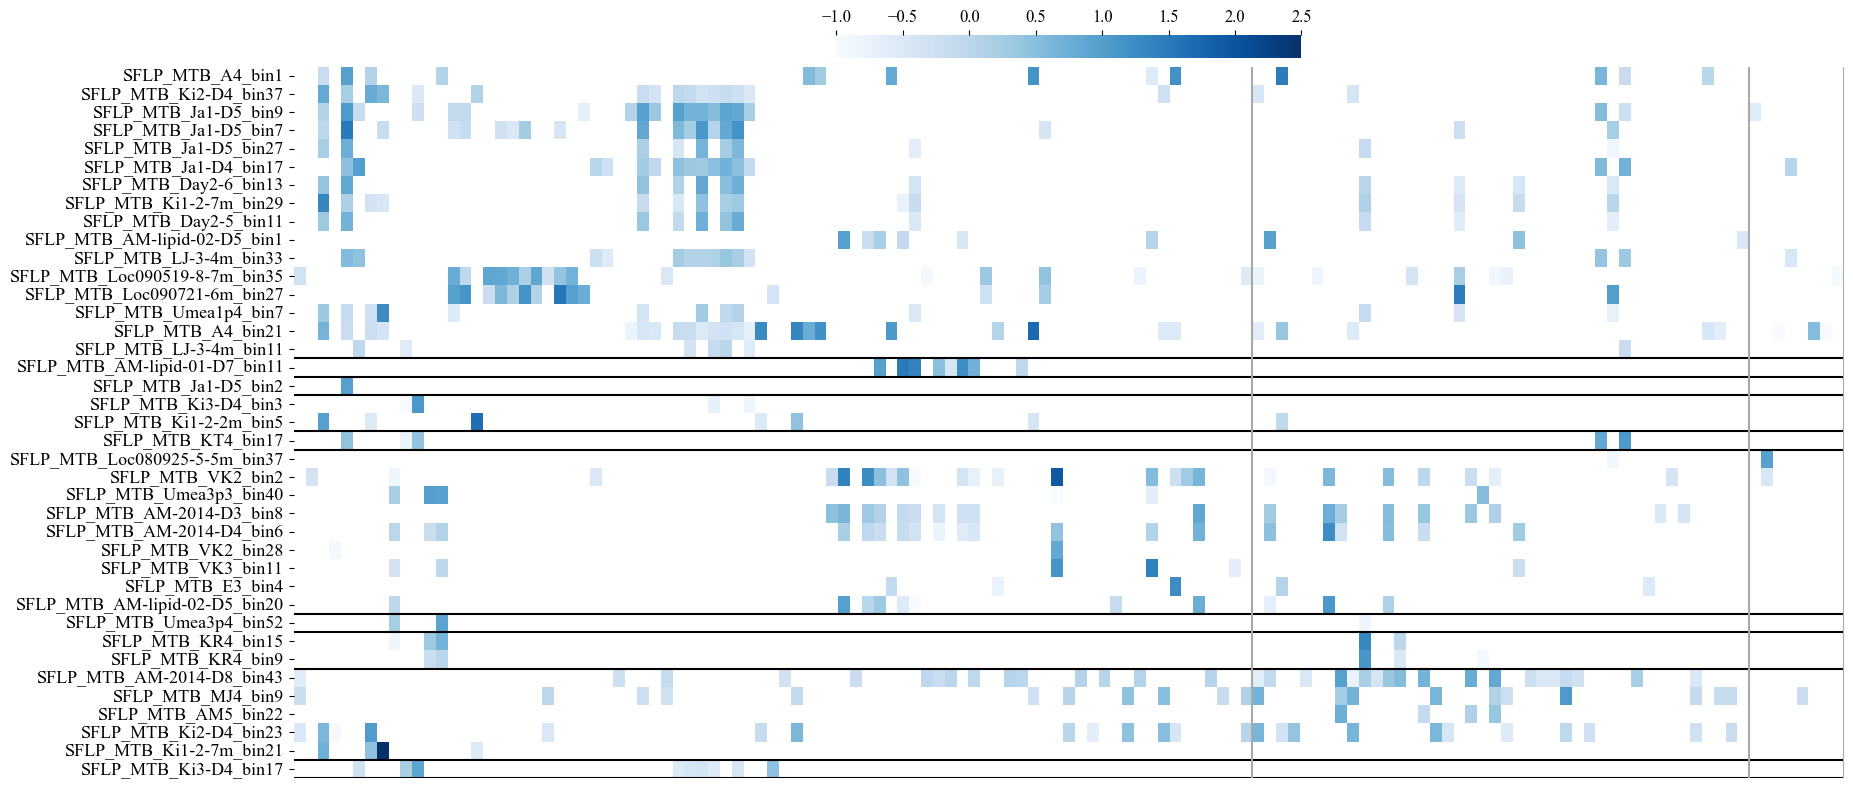

In [75]:
# plot the heatmap of MTB MAG across all samples 
plt.figure(figsize=(20,11))
ax = sns.heatmap(np.log10(MTB_abd_lineage_df.iloc[:,:-1]), vmin=-1, vmax=2.5, cmap='Blues',
                linecolor='white', linewidth=0, cbar_kws={"shrink": 0.3, 'location':"top",'pad':0.01},
                )
plt.xticks([])
plt.yticks(fontsize=13)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
ax.hlines([16, 17, 18, 20, 21, 30, 31, 33, 38, 39], *ax.get_xlim(), color='black')# Seperate MTB bins accorrding to their taxa
ax.vlines([81, 123, 131], *ax.get_xlim(), color='darkgrey')# Seperate samples accorrding to the oxygen zone
# plt.savefig('tmp.svg')

(array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. ]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.5, '0.5'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.5, '1.5'),
  Text(0, 2.0, '2.0'),
  Text(0, 2.5, '2.5'),
  Text(0, 3.0, '3.0')])

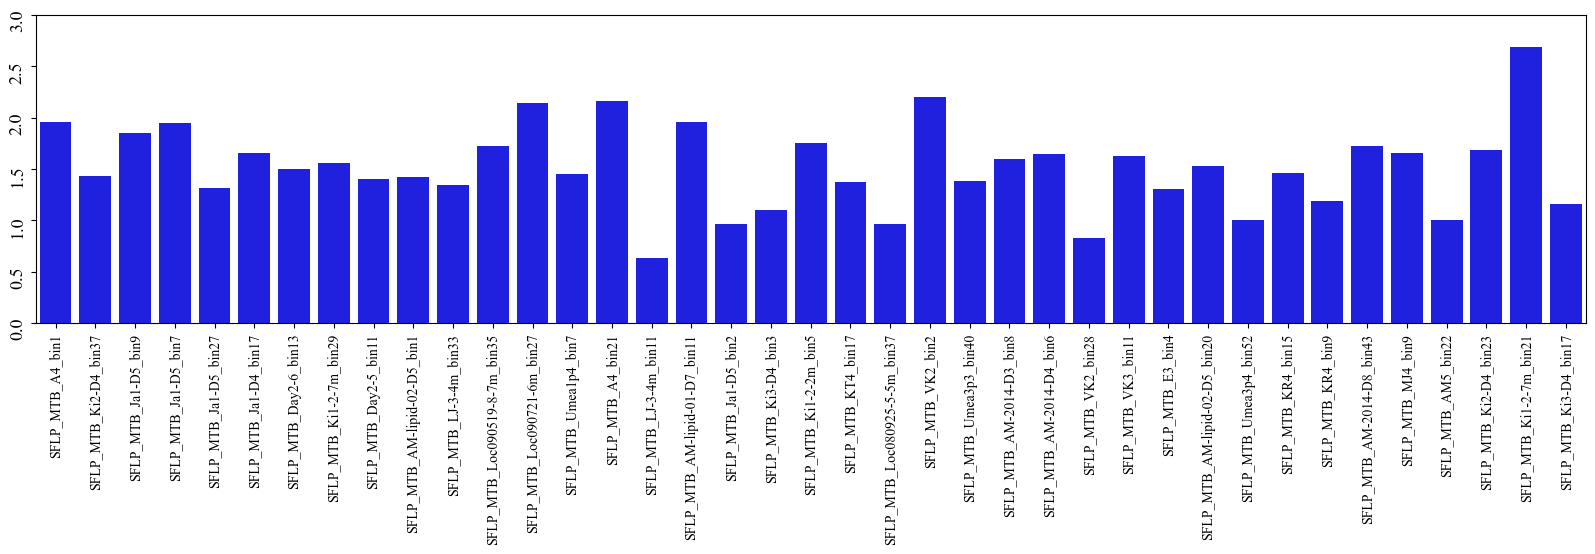

In [76]:
# Draw the barplot to demonstrate the sum of the abundance for each MAG
tmp = np.log10(MTB_abd_lineage_df.sum(numeric_only=True,axis=1))
x = tmp.index.tolist()
y = tmp.tolist()
plt.figure(figsize=(20,4))
sns.barplot(x=x, y=y, color='blue')
plt.xticks(rotation=90,ha='center')
plt.ylim(0,3)
plt.yticks(fontsize=13, rotation=90)
# plt.savefig('tmp1.svg',bbox_inches='tight')

(array([-1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ]),
 [Text(0, -1.5, '−1.5'),
  Text(0, -1.0, '−1.0'),
  Text(0, -0.5, '−0.5'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.5, '0.5'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.5, '1.5'),
  Text(0, 2.0, '2.0'),
  Text(0, 2.5, '2.5'),
  Text(0, 3.0, '3.0')])

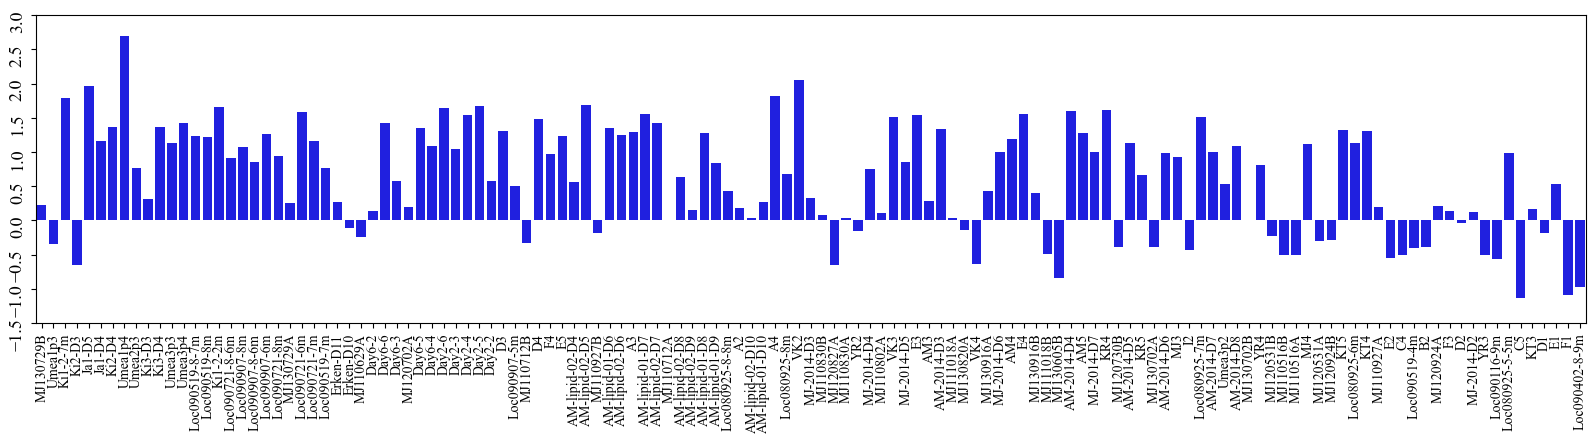

In [77]:
# Draw the barplot to demonstrate the sum of the abundance for each sample
tmp = np.log10(MTB_abd_lineage_df.sum(numeric_only=True))
x = tmp.index.tolist()
y = tmp.tolist()

plt.figure(figsize=(20, 4))
sns.barplot(x=x, y=y, color='blue')
plt.xticks(rotation=90,ha='center')
plt.ylim(-1.5,3)
plt.yticks(fontsize=13, rotation=90)
# plt.savefig('tmp2.svg',bbox_inches='tight')

##### 5.2.3 Count the number of samples containing different lineage of MTB

In [78]:
delta

['p__Desulfobacterota',
 'p__Desulfobacterota_I',
 'p__Desulfobacterota_G',
 'p__Bdellovibrionota',
 'p__Myxococcota']

In [79]:
# Count the number of samples where MTB of different phyla are exist
MTB_abd_lineage_df['taxa'] = MTB_abd_lineage_df.phylum.apply(lambda x: 
                                'Deltaproteobacteria' if x in delta 
                                else ('Alphaproteobacteria' if 'Alphaproteobacteria' in x 
                                      else ('Etaproteobacteria' if 'Magnetococcia' in x else x)))

tmp = MTB_abd_lineage_df.groupby('taxa').agg('sum').iloc[:,:-1].copy()
tmp.replace(0,np.nan, inplace=True)

for n, row in tmp.iterrows():
    dftmp = pd.DataFrame(row.dropna())
    num_of_samples=len(dftmp)
    dftmp['oxygen']=meta_df['oxygen']
    dftmp['oxic_zone'] = dftmp.oxygen.apply(lambda x: 'oxic' if x >=2 else ('hypoxic' if x>=0.5 else 'anoxic'))
    print(n, num_of_samples)
    print(dftmp.oxic_zone.value_counts())

Alphaproteobacteria 40
oxic_zone
anoxic     24
hypoxic    15
oxic        1
Name: count, dtype: int64
Deltaproteobacteria 83
oxic_zone
anoxic     60
hypoxic    17
oxic        6
Name: count, dtype: int64
Etaproteobacteria 3
oxic_zone
anoxic     2
hypoxic    1
Name: count, dtype: int64
p__Hydrogenedentota 9
oxic_zone
anoxic    9
Name: count, dtype: int64
p__Omnitrophota 60
oxic_zone
anoxic     32
hypoxic    27
oxic        1
Name: count, dtype: int64
p__Proteobacteria;c__Gammaproteobacteria 6
oxic_zone
anoxic     3
hypoxic    3
Name: count, dtype: int64


##### 5.2.4 Investigate the difference of MTB abundance of Delta-, Alpha-, Omnitrophota MTB across the oxygen zones

In [80]:
tmp = MTB_abd_lineage_df.drop('phylum',axis=1)
tmp.set_index('taxa', inplace=True)
tmp=pd.DataFrame(tmp.loc[['Deltaproteobacteria','Alphaproteobacteria','p__Omnitrophota'],:].stack()).reset_index().rename(columns={0:'abundance','level_1':'sample_id'})
tmp.set_index('sample_id',inplace=True)
tmp['oxygen'] = meta_df['oxygen']
tmp['oxic_zone'] = tmp.oxygen.apply(lambda x: 'oxic' if x >=2 else ('hypoxic' if x>=0.5 else 'anoxic'))
tmp['abundance(log10)'] = tmp.abundance.apply(lambda x: np.log10(x))
tmp

,taxa,abundance,oxygen,oxic_zone,abundance(log10)
sample_id,,,,,
Ki1-2-7m,Deltaproteobacteria,0.681507,0.00,anoxic,-0.166530
Ja1-D5,Deltaproteobacteria,9.372504,0.00,anoxic,0.971856
Ki2-D4,Deltaproteobacteria,1.197921,0.00,anoxic,0.078428
Umea3p4,Deltaproteobacteria,1.218055,0.00,anoxic,0.085667
F4,Deltaproteobacteria,3.581436,0.22,anoxic,0.554057
...,...,...,...,...,...
MJ-2014-D2,p__Omnitrophota,0.622679,1.90,hypoxic,-0.205736
Ki1-2-7m,p__Omnitrophota,5.130001,0.00,anoxic,0.710117
Ki2-D4,p__Omnitrophota,2.814936,0.00,anoxic,0.449469


Text(0, 0.5, 'Density')

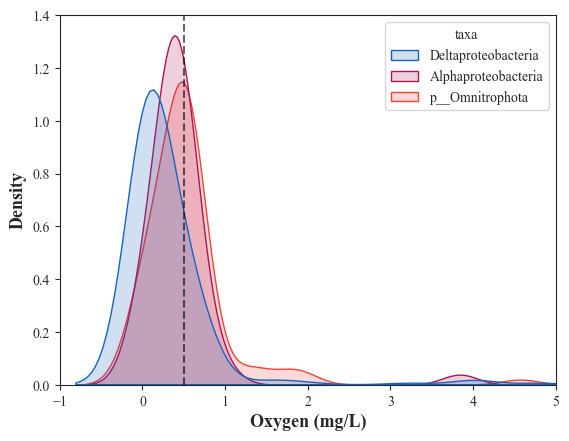

In [81]:
# Draw the density plot to illustrate the oxgen ranges where Delta, Alpha, and Omnitrophota MTB lives
sns.set_style('ticks')
plt.rcParams['font.family'] = 'Times New Roman'
ax=sns.kdeplot(
   data=tmp, x="oxygen", hue="taxa",
   fill=True, palette=['#1565c04d', '#ad1457ff', '#f44336ff'],
   alpha=.2, linewidth=1,common_norm=False
)
plt.xlim(-1, 5)
plt.ylim(0, 1.4)
ax.axvline(x = 0.5, ymin = 0, color='black', linestyle='dashed',alpha=0.6)
plt.xlabel('Oxygen (mg/L)',fontsize=13, weight='bold')
plt.ylabel('Density',fontsize=13, weight='bold')
# plt.savefig('Fig6d.svg', bbox_inches='tight')

(array([0, 1, 2]),
 [Text(0, 0, 'Deltaproteobacteria'),
  Text(1, 0, 'Alphaproteobacteria'),
  Text(2, 0, 'p__Omnitrophota')])

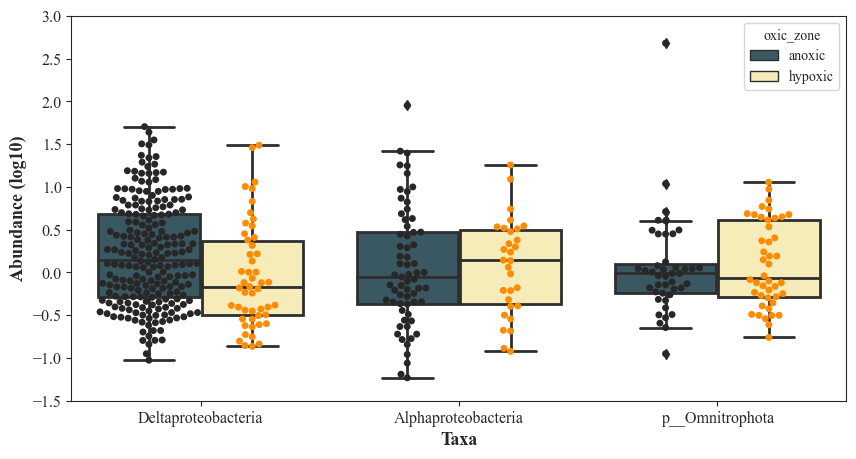

In [82]:
# Analyse the abundance value of different MTB lineage in different oxygen zones
plt.figure(figsize=(10,5))
plt.rcParams['font.family'] = 'Times New Roman'
sns.boxplot(data=tmp[tmp.oxic_zone!='oxic'], x="taxa", y="abundance(log10)", hue="oxic_zone", 
             palette=['#335C67','#FFF3B0'],linewidth=2,)
sns.swarmplot(data=tmp[tmp.oxic_zone!='oxic'], x="taxa", y="abundance(log10)", hue="oxic_zone", 
              legend=False,dodge=True,palette=['#272727','darkorange'], alpha=1,
             size=5)
plt.xlabel('Taxa', fontsize=13, weight='bold')
plt.ylabel('Abundance (log10)', fontsize=13, weight='bold')
plt.ylim(-1.5,3)
plt.yticks(fontsize=11.5)
plt.xticks(fontsize=11.5)
# plt.savefig('Fig6e.svg', bbox_inches='tight')

In [83]:
# Analyse the difference of Deltaproteobacteria MTB abundance between anoxic zone and hypoxic zone
delta_anoxic_abd = tmp[(tmp.taxa=='Deltaproteobacteria') & (tmp.oxic_zone=='anoxic')]['abundance'].tolist()
delta_hypoxic_abd = tmp[(tmp.taxa=='Deltaproteobacteria') & (tmp.oxic_zone=='hypoxic')]['abundance'].tolist()

# Delproteobacteria MTB abundance data in anoxic and hypoxic are not normally distributed
s0,p0 = stats.normaltest(delta_anoxic_abd)
s1,p1 = stats.normaltest(delta_hypoxic_abd)
print(p0, p1)

4.531942802375196e-42 6.934601056606382e-15


In [84]:
# employ mannwhitneyu to test the difference of deltaproteobacteria MTB abundaces between anoxic zone and hypoxic zone
U,p=stats.mannwhitneyu(delta_anoxic_abd,delta_hypoxic_abd)
print(p)

0.004036011972265541


In [85]:
# Analyse the difference Alphaproteobacteria MTB abundance between anoxic zone and hypoxic zone
Alpha_anoxic_abd = tmp[(tmp.taxa=='Alphaproteobacteria') & (tmp.oxic_zone=='anoxic')]['abundance'].tolist()
Alpha_hypoxic_abd = tmp[(tmp.taxa=='Alphaproteobacteria') & (tmp.oxic_zone=='hypoxic')]['abundance'].tolist()

# Alphaproteobacteria MTB abundance data in anoxic and hypoxic are not normally distributed
s0,p0 = stats.normaltest(Alpha_anoxic_abd)
s1,p1 = stats.normaltest(Alpha_hypoxic_abd)
print(p0, p1)

8.960387787554056e-26 9.274219764067259e-10


In [86]:
# employ mannwhitneyu to test the difference of Alphaproteobacteria MTB abundaces between anoxic zone and hypoxic zone
U,p=stats.mannwhitneyu(Alpha_anoxic_abd,Alpha_hypoxic_abd)
print(p)

0.7276308627067094


In [87]:
# Analyse the difference Omnitrophota MTB abundance between anoxic zone and hypoxic zone
Omnitro_anoxic_abd = tmp[(tmp.taxa=='p__Omnitrophota') & (tmp.oxic_zone=='anoxic')]['abundance'].tolist()
Omnitro_hypoxic_abd = tmp[(tmp.taxa=='p__Omnitrophota') & (tmp.oxic_zone=='hypoxic')]['abundance'].tolist()

# Omnitrophota MTB abundance data in anoxic and hypoxic are not normally distributed
s0,p0 = stats.normaltest(Omnitro_anoxic_abd)
s1,p1 = stats.normaltest(Omnitro_hypoxic_abd)
print(p0, p1)

4.839006111393142e-22 1.6605531376869072e-05


In [88]:
# employ mannwhitneyu to test the difference of Omnitrophota MTB abundaces between anoxic zone and hypoxic zone
U,p=stats.mannwhitneyu(Omnitro_anoxic_abd,Omnitro_hypoxic_abd)
print(p)

0.5608768380400371
